# **SI 618 - Project: Geospatial Analysis of Policies and Mental Health in Sexual Minority Youth**

Group Members: Amanpreet Bhogal, Jonathan Kang, and Kelly Nguyen


# **Project Overview**


The following project will examine the relationship between harmful/protective LGBTQIA+ policies by state, and their impact on sexual minority youth mental health outcomes. Specifically, we are interested in examining sexual minority youth suicidal ideation. 

## Motivation

The prevalence of diagnosed mental or behavioral health conditions has increased by 36 percent between the years 2016 and 2023 (Sappenfield et al., 2024), highlighting the need to examine risk factors for poor youth mental health. Prior work by Price and Mulkern (2025) emphasized the relation of sociopolitical climate as central to understanding health trajectories for stigmatized populations (e.g., LGBTQ+ youth). Data from the Adolescent Brain and Cognitive Development study found that cisgender LGBTQ+ youth living in areas with higher (vs. lower) levels of structural homophobia experience more mental health problems. Building upon prior findings that highlight spatial disparities in youth mental health, this project will examine the relationship between state-level LGBTQIA+ policies and suicidal ideation among sexual minority youth. By linking policy indices (harmful/protective laws) to mental health outcomes, this analysis aims to identify geographic patterns of risk, informing policy interventions and public health strategies.



## Research Questions
1. **Are sexual minority youth at higher risk for suicidal ideation than heterosexual youth?**
2. **Do harmful/protective LGBTQIA+ policies impact youth suicidal ideation?**
3. **How do state-level policy environments and geographic location influence suicidal ideation among sexual minority youth?**

## Data Sources

Census Bureau TIGER/Line Shapefiles: https://www2.census.gov/geo/tiger/GENZ2022/shp/

Youth Risk Behavior Surveillance System (YRBSS): https://www.cdc.gov/yrbs/data/index.html

LGBTQ+ Policy Data: https://www.icpsr.umich.edu/web/RCMD/studies/37877


The Census Bureau TIGER/Line shapefiles are map files that contain geometric boundaries of geographic entities, such as, U.S. states. Each shapefile has an attribute table with one row per geographic feature (e.g., per state). These attributes are our key identifiers to join external data (e.g., YRBSS and LGBTQ+ policy data) to the shapefile. The CDC's Youth Risk Behavior Surveillance System data contains information regarding youth sexual identity, mental health status, and state-level geographic location. The data is broken up into smaller files by states. All YRBSS files will be merged to create a national sample. The LGBTQ+ policy data contains policy tallies for each state where lower numbers reflect more harmful policies and higher numbers reflect protective policies for LGBTQ+ individuals. By utilizing the shapefile, we can link data on LGBTQ+ youth mental health and policies at each state's geographic location. This will be done by using the "name" variable in the shapefile, and state names from the YRBSS data and policy data. 





## Import libraries

In [201]:
# Load in pacakages necessary for data cleaning and analysis
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency, chi2
from statsmodels.tools.sm_exceptions import PerfectSeparationError
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm # colormaps
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as shc
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

## Import Shapefiles

In [202]:
# Import shapefiles
shp_path = Path("cb_2022_us_state_20m/cb_2022_us_state_20m.shp")
gdf = gpd.read_file(shp_path).to_crs(4326)

## Ensure Shapefiles Imported Correctly

In [203]:
# Inspect shapefile data
gdf.head()

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,48,01779801,0400000US48,48,TX,Texas,00,676685555821,18974391187,"POLYGON ((-106.62344 31.91403, -106.63011 31.9..."
1,06,01779778,0400000US06,06,CA,California,00,403673617862,20291712025,"MULTIPOLYGON (((-118.59397 33.4672, -118.48478..."
2,21,01779786,0400000US21,21,KY,Kentucky,00,102266581101,2384240769,"POLYGON ((-89.54443 36.57451, -89.47935 36.566..."
3,13,01705317,0400000US13,13,GA,Georgia,00,149486268417,4418716153,"POLYGON ((-85.60516 34.98468, -85.47434 34.983..."
4,55,01779806,0400000US55,55,WI,Wisconsin,00,140292518676,29343193162,"MULTIPOLYGON (((-86.93428 45.42115, -86.83575 ..."


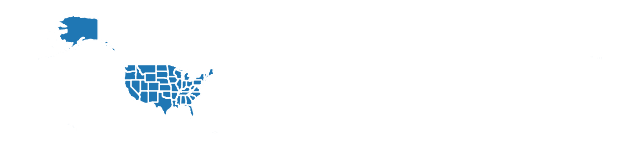

In [204]:
# Visualize shape data to ensure the shapefile imported correctly
ax = gdf.plot(edgecolor="white", figsize=(8,5))
ax.set_axis_off()

## Import YRBSS Datasets

In [205]:
# Import data from directory

"""
DESC: Load all CSV files from a directory into individual variables

PARAMS:
    my_path: str - The path to the directory containing the CSV files

RETURNS:
    tuple - A tuple containing the DataFrames for each CSV file
"""
def load_data_from_dir(my_path):
    """Load all CSV files from a directory into individual variables."""

    # Create an empty list to store the the data frames
    dataframes = []

    # Use list comprehension to get the filenames of all the CSVs in the directory
    filenames = sorted([f for f in os.listdir(my_path) if f.endswith('.csv')])

    # Loop through the filenames and read each CSV into a DataFrame
    for filename in filenames:
        df = pd.read_csv(os.path.join(my_path, filename))
        dataframes.append(df)

    # Return the dataframes as a tuple
    return tuple(dataframes)


# Load the data
# variable assignment known as tuple unpacking
sadc_2023_state_ad, sadc_2023_state_eh, sadc_2023_state_il, sadc_2023_state_mbis, sadc_2023_state_np, sadc_2023_state_qt, sadc_2023_state_uz = \
    load_data_from_dir("state_data")

# You may need to change the my_path argument to the directory where your CSV files are located ^^^

## Import Policy Data

In [206]:
# Import policy data
policy = pd.read_csv("/Users/jonathankang/Documents/SI 618/project/policy_data/policy_2020_data.csv")
policy.head()

,V001,V002,V003,V004,V005,V006,V007,V008,V009,V010,...,V087,V088,V089,V090,V091,V092,V093,V094,V095,V096
0,Alabama,-6.50,(1) Negative: Less than zero,-2.00,(1) Negative: Less than zero,-4.50,(1) Negative: Less than zero,1.50,0.0,-5.0,...,0.00,(0) State does not prohibit use of 'gay panic ...,0.0,0.00,(0) If state does not prohibit use of 'trans p...,0.0,-1.00,0.0,-1.0,(1) Does not require public announcement of na...
1,Alaska,3.75,(2) Low: 0-24.9% of total possible points,2.50,(2) Low: 0-24.9% of total possible sexual orie...,1.25,(2) Low: 0-24.9% of total possible gender iden...,1.50,2.0,0.0,...,-0.25,(0) State does not prohibit use of 'gay panic ...,0.0,-0.25,(0) If state does not prohibit use of 'trans p...,0.0,0.75,0.0,1.0,(0) Requirement of public announcement of name...
2,Arizona,3.75,(2) Low: 0-24.9% of total possible points,5.25,(3) Fair: 25-49.9% of total,-1.50,(1) Negative: Less than zero,2.50,2.0,-1.0,...,0.00,(0) State does not prohibit use of 'gay panic ...,0.0,0.00,(0) If state does not prohibit use of 'trans p...,0.0,0.25,0.0,-1.0,(0) Requirement of public announcement of name...
3,Arkansas,0.50,(2) Low: 0-24.9% of total possible points,1.00,(2) Low: 0-24.9% of total possible sexual orie...,-0.50,(1) Negative: Less than zero,2.00,-2.0,-1.0,...,-1.00,(0) State does not prohibit use of 'gay panic ...,0.0,-1.00,(0) If state does not prohibit use of 'trans p...,0.5,1.00,0.0,-1.0,(1) Does not require public announcement of na...
4,California,34.75,(5) High: 75-100% of total,16.50,(5) High: 75-100% of total,18.25,(5) High: 75-100% of total,6.25,7.0,0.0,...,-0.25,(1) State prohibits use of defense,1.0,-0.25,(1) If state prohibits use of defense,0.5,1.00,0.5,1.0,(1) Does not require public announcement of na...


In [207]:
# Enter the midpoint of the data for analyses 
policy['V005_MP'] = policy['V005'].apply(lambda x: -1 if x == '(1) Negative: Less than zero'
else 12.45 if x == '(2) Low: 0-24.9% of total possible sexual orientation points'
else 37.45 if x == '(3) Fair: 25-49.9% of total'
else 62.45 if x == '(4) Medium: 50-74.9% of total'
else 87.5
)

In [208]:
# Check data to make sure changes were made correctly 
policy.head()

,V001,V002,V003,V004,V005,V006,V007,V008,V009,V010,...,V088,V089,V090,V091,V092,V093,V094,V095,V096,V005_MP
0,Alabama,-6.50,(1) Negative: Less than zero,-2.00,(1) Negative: Less than zero,-4.50,(1) Negative: Less than zero,1.50,0.0,-5.0,...,(0) State does not prohibit use of 'gay panic ...,0.0,0.00,(0) If state does not prohibit use of 'trans p...,0.0,-1.00,0.0,-1.0,(1) Does not require public announcement of na...,-1.00
1,Alaska,3.75,(2) Low: 0-24.9% of total possible points,2.50,(2) Low: 0-24.9% of total possible sexual orie...,1.25,(2) Low: 0-24.9% of total possible gender iden...,1.50,2.0,0.0,...,(0) State does not prohibit use of 'gay panic ...,0.0,-0.25,(0) If state does not prohibit use of 'trans p...,0.0,0.75,0.0,1.0,(0) Requirement of public announcement of name...,12.45
2,Arizona,3.75,(2) Low: 0-24.9% of total possible points,5.25,(3) Fair: 25-49.9% of total,-1.50,(1) Negative: Less than zero,2.50,2.0,-1.0,...,(0) State does not prohibit use of 'gay panic ...,0.0,0.00,(0) If state does not prohibit use of 'trans p...,0.0,0.25,0.0,-1.0,(0) Requirement of public announcement of name...,37.45
3,Arkansas,0.50,(2) Low: 0-24.9% of total possible points,1.00,(2) Low: 0-24.9% of total possible sexual orie...,-0.50,(1) Negative: Less than zero,2.00,-2.0,-1.0,...,(0) State does not prohibit use of 'gay panic ...,0.0,-1.00,(0) If state does not prohibit use of 'trans p...,0.5,1.00,0.0,-1.0,(1) Does not require public announcement of na...,12.45
4,California,34.75,(5) High: 75-100% of total,16.50,(5) High: 75-100% of total,18.25,(5) High: 75-100% of total,6.25,7.0,0.0,...,(1) State prohibits use of defense,1.0,-0.25,(1) If state prohibits use of defense,0.5,1.00,0.5,1.0,(1) Does not require public announcement of na...,87.50


## Data Description 

1. Shapefile - For the shapefile data, we will be utilizing 'NAME' since we have names of each of the states in all of our datasets. 
2. Policy data - For the policy data, we will subset it to only include the state name and the sexual orientation policy tally since our analyses are focused on sexual minority youth. 
3. YRBS data - For the YRBS data, we will subset the data so that it includes data from 2021 onwards. This is because data was not collected on sexual identity prior to 2021. Further, we will subset the data to include state name, age, sex, sexual identity, and our outcome variable that collects whether youth endorsed saying yes or no to whether youth considered suicide.  



In [209]:
# View the number of missing values in each column
policy.isna().sum()

V001       0
V002       0
V003       0
V004       0
V005       0
          ..
V093       0
V094       0
V095       0
V096       0
V005_MP    0
Length: 97, dtype: int64

In [210]:
# View data types of each column
policy.dtypes

V001        object
V002       float64
V003        object
V004       float64
V005        object
            ...   
V093       float64
V094       float64
V095       float64
V096        object
V005_MP    float64
Length: 97, dtype: object

In [211]:
# View column names
policy.columns

Index(['V001', 'V002', 'V003', 'V004', 'V005', 'V006', 'V007', 'V008', 'V009',
       'V010', 'V011', 'V012', 'V013', 'V014', 'V015', 'V016', 'V017', 'V018',
       'V019', 'V020', 'V021', 'V022', 'V023', 'V024', 'V025', 'V026', 'V027',
       'V028', 'V029', 'V030', 'V031', 'V032', 'V033', 'V034', 'V035', 'V036',
       'V037', 'V038', 'V039', 'V040', 'V041', 'V042', 'V043', 'V044', 'V045',
       'V046', 'V047', 'V048', 'V049', 'V050', 'V051', 'V052', 'V053', 'V054',
       'V055', 'V056', 'V057', 'V058', 'V059', 'V060', 'V061', 'V062', 'V063',
       'V064', 'V065', 'V066', 'V067', 'V068', 'V069', 'V070', 'V071', 'V072',
       'V073', 'V074', 'V075', 'V076', 'V077', 'V078', 'V079', 'V080', 'V081',
       'V082', 'V083', 'V084', 'V085', 'V086', 'V087', 'V088', 'V089', 'V090',
       'V091', 'V092', 'V093', 'V094', 'V095', 'V096', 'V005_MP'],
      dtype='object')

In [212]:
# View the shape of each dataframe
dataframes = [sadc_2023_state_ad, sadc_2023_state_eh, sadc_2023_state_il, sadc_2023_state_mbis, sadc_2023_state_np, sadc_2023_state_qt, sadc_2023_state_uz]

for i, df in enumerate(dataframes):
    print(f"csv{i}: {df.shape}")

csv0: (105455, 269)
csv1: (126244, 269)
csv2: (127796, 269)
csv3: (482864, 269)
csv4: (332732, 269)
csv5: (98021, 269)
csv6: (280797, 269)


In [213]:
# Combine all YRBS dataframes into one
combined_df = pd.concat([dataframes[0], dataframes[1], dataframes[2], dataframes[3], dataframes[4], dataframes[5], dataframes[6]])

In [214]:
# Create a copy of the combined dataframe
df = combined_df.copy()

# Treat both real NaN and the literal string "Missing" as missing
is_missing = df["sexid2"].isna() | df["sexid2"].eq("Missing")

# Calculate total and missing counts by year
by_year = (
    df.assign(is_missing=is_missing)
      .groupby("year", as_index=False)
      .agg(total=("sexid2", "size"), missing=("is_missing", "sum"))
      .assign(pct_missing=lambda d: 100 * d["missing"] / d["total"])
      .sort_values("year")
)

by_year

,year,total,missing,pct_missing
0,1991,28376,28376,100.000000
1,1993,58975,58975,100.000000
2,1995,48443,48443,100.000000
3,1997,44048,44048,100.000000
4,1999,39454,39454,100.000000
5,2001,51240,51240,100.000000
6,2003,56927,56927,100.000000
7,2005,81186,81186,100.000000
8,2007,80672,80672,100.000000
9,2009,89124,89124,100.000000


There is no data on sexual identity until 2021. We are going to subset the data to only include data from the years 2021 and 2023 since sexual identity is a key variable in our study. 

In [215]:
# There is no data on sexual identity until 2021. We are going to subset the data to only include data from the years 2021 and 2023.
combined_df = combined_df[combined_df["year"] > 2019]

In [216]:
# Filter to variables of interest
filtered = combined_df[["sitecode", "year", "age", "sex", "race7", "sexid2", "q27"]]
filtered

,sitecode,year,age,sex,race7,sexid2,q27
99391,Alabama,2021,12 years old or younger,Missing,Missing,Missing,Yes
99392,Alabama,2021,14 years old,Missing,Missing,Missing,Missing
99393,Alabama,2021,14 years old,Missing,Hispanic/Latino,Missing,Missing
99394,Alabama,2021,15 years old,Missing,Missing,Missing,Missing
99395,Alabama,2021,17 years old,Missing,Missing,Missing,Missing
...,...,...,...,...,...,...,...
280792,Wisconsin,2023,18 years old or older,Female,White,Heterosexual,No
280793,Wisconsin,2023,18 years old or older,Female,White,Heterosexual,No
280794,Wisconsin,2023,18 years old or older,Female,White,Heterosexual,No
280795,Wisconsin,2023,18 years old or older,Female,White,Other/Questioning,No


In [217]:
# View column names of filtered dataframe
filtered.columns

Index(['sitecode', 'year', 'age', 'sex', 'race7', 'sexid2', 'q27'], dtype='object')

In [218]:
# View number of missing values in each column of filtered dataframe
filtered.isna().sum()

sitecode    0
year        0
age         0
sex         0
race7       0
sexid2      0
q27         0
dtype: int64

## Data Manipulation Pt 1

1. Ensure the state names are spelled correctly in each dataframe.  
2. Subset data to only include variables of interest that were described above. 
3. Merge all dataFrames


In [219]:
# Check to make sure the state names are spelled correctly
filtered['sitecode'].unique()

array(['Alabama', 'Arkansas', 'Arizona', 'Colorado', 'Alaska', 'Florida',
       'Georgia', 'Hawaii', 'Iowa', 'Idaho', 'Illinois', 'Indiana',
       'Kansas', 'Kentucky', 'Maryland', 'Michigan', 'Missouri',
       'Mississippi', 'Montana', 'Massachusetts', 'North Carolina',
       'North Dakota', 'Nebraska', 'New Hampshire', 'New Jersey',
       'New Mexico', 'Nevada', 'New York (Excluding NYC)', 'Oklahoma',
       'Pennsylvania', 'South Carolina', 'Tennessee', 'Texas', 'Utah',
       'Virginia', 'Vermont', 'Wisconsin'], dtype=object)

New York has been written as "New York (Excluding NYC)" which will not match with the shapefile. We will have to rename this response to be New York.

In [220]:
# Replace "New York (Excluding NYC)" with "New York"
filtered['sitecode'] = filtered['sitecode'].replace("New York (Excluding NYC)", "New York")

/var/folders/r0/xthhjg_15bb1p7sb1tfbqng40000gn/T/ipykernel_42453/770213885.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['sitecode'] = filtered['sitecode'].replace("New York (Excluding NYC)", "New York")


In [221]:
# Check again to make sure the state names are spelled correctly
filtered['sitecode'].unique()

array(['Alabama', 'Arkansas', 'Arizona', 'Colorado', 'Alaska', 'Florida',
       'Georgia', 'Hawaii', 'Iowa', 'Idaho', 'Illinois', 'Indiana',
       'Kansas', 'Kentucky', 'Maryland', 'Michigan', 'Missouri',
       'Mississippi', 'Montana', 'Massachusetts', 'North Carolina',
       'North Dakota', 'Nebraska', 'New Hampshire', 'New Jersey',
       'New Mexico', 'Nevada', 'New York', 'Oklahoma', 'Pennsylvania',
       'South Carolina', 'Tennessee', 'Texas', 'Utah', 'Virginia',
       'Vermont', 'Wisconsin'], dtype=object)

In [222]:
# Create a copy of the filtered dataframe
copy = filtered
# Replace "Missing" with NaN
copy.replace("Missing", np.nan, inplace=True)
# Reset index
copy = copy.reset_index()
# View the first few rows of the cleaned dataframe
copy.head()

/var/folders/r0/xthhjg_15bb1p7sb1tfbqng40000gn/T/ipykernel_42453/1305238816.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  copy.replace("Missing", np.nan, inplace=True)


,index,sitecode,year,age,sex,race7,sexid2,q27
0,99391,Alabama,2021,12 years old or younger,NaN,NaN,NaN,Yes
1,99392,Alabama,2021,14 years old,NaN,NaN,NaN,NaN
2,99393,Alabama,2021,14 years old,NaN,Hispanic/Latino,NaN,NaN
3,99394,Alabama,2021,15 years old,NaN,NaN,NaN,NaN
4,99395,Alabama,2021,17 years old,NaN,NaN,NaN,NaN


We created a copy of our data and reset the index for a clean copy of our dataframe that we could further manipulate. 

## Data Visualization
1. Create histogram for sex
2. Create histogram for age categories
3. Create histogram for sexual identity to see breakdown of different sexual orientation identities in our dataframe. 
3. Create unstacked bar chart for age categories to see suicidal ideation

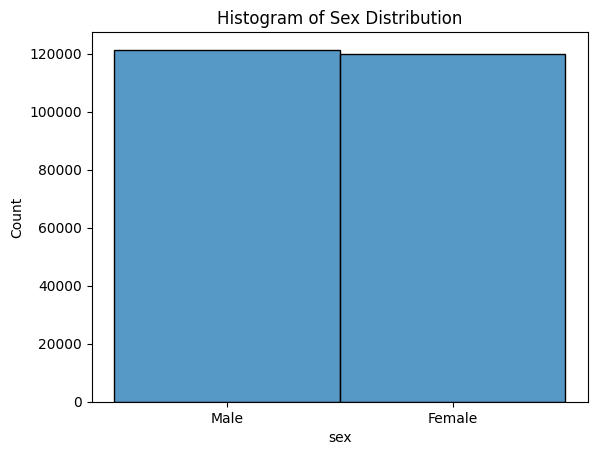

In [223]:
# Create a histogram to visualize the distribution of sex
sex_hist = sns.histplot(x="sex",data=copy)
sex_hist.set_title("Histogram of Sex Distribution")
plt.show()

In the histogram of sex for the questionnaire dataset, the options displayed has roughly the same amount of respondants. There seems to be slightly more female respondants than male respondants. Both categorties have  a frequency of about about 260,000.

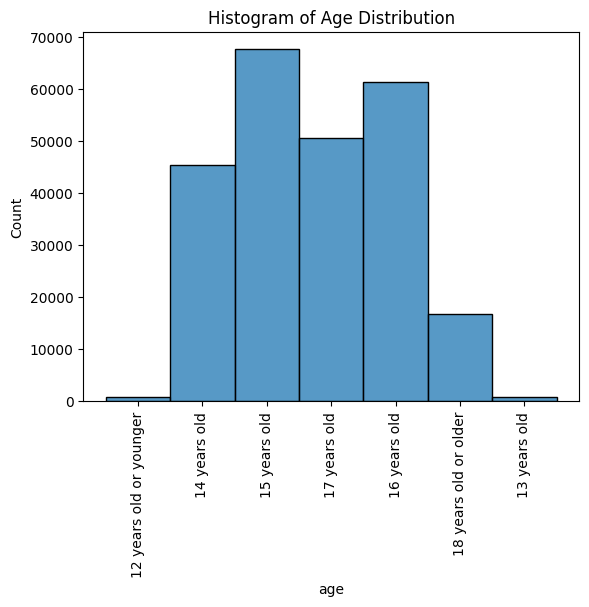

In [224]:
# Create a histogram to visualize the distribution of age
age_hist = sns.histplot(x="age", data=copy)

_ = plt.xticks(rotation=90)
age_hist.set_title("Histogram of Age Distribution")
plt.show()

The plot above represents the ages of respondants. A majority of the data is collected from those ages 15, 16, and 17 years old. Those aged 13 and 12 and younger have the least number of responses.

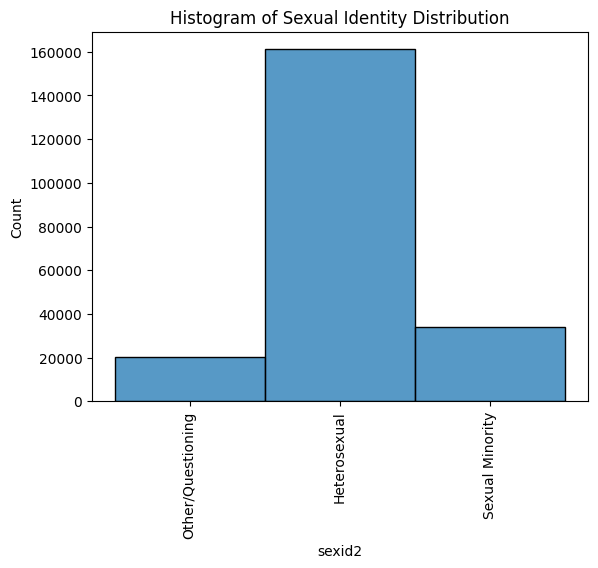

In [225]:
# Create a histogram to visualize the distribution of sexual identity
sexid_hist = sns.histplot(x="sexid2", data=copy)

_ = plt.xticks(rotation=90)
sexid_hist.set_title("Histogram of Sexual Identity Distribution")
plt.show()

The plot above shows a histogram of individuals with different sexual orientations. It is clear that there are far more heterosexual youth in our data compared to sexual minority youth. This is in line with prior literature and the national distribution of sexual orientation. 

In [226]:
# Convert age to numeric by extracting the number from the age string
copy['age_num'] = copy['age'].str.split(' ').str[0].astype(float)
copy

,index,sitecode,year,age,sex,race7,sexid2,q27,age_num
0,99391,Alabama,2021,12 years old or younger,NaN,NaN,NaN,Yes,12.0
1,99392,Alabama,2021,14 years old,NaN,NaN,NaN,NaN,14.0
2,99393,Alabama,2021,14 years old,NaN,Hispanic/Latino,NaN,NaN,14.0
3,99394,Alabama,2021,15 years old,NaN,NaN,NaN,NaN,15.0
4,99395,Alabama,2021,17 years old,NaN,NaN,NaN,NaN,17.0
...,...,...,...,...,...,...,...,...,...
243839,280792,Wisconsin,2023,18 years old or older,Female,White,Heterosexual,No,18.0
243840,280793,Wisconsin,2023,18 years old or older,Female,White,Heterosexual,No,18.0
243841,280794,Wisconsin,2023,18 years old or older,Female,White,Heterosexual,No,18.0
243842,280795,Wisconsin,2023,18 years old or older,Female,White,Other/Questioning,No,18.0


We are now going to start aggregating our data. This is being done because in geospatial data, each state should only have one row of data. Since each of our variables are categorical, we will be creating proportions to aggregate them per state. 

In [227]:
# Create function to aggregate q27 data
def q27_summary(df):
    total = len(df)
    missing = df["q27"].isna().sum()
    q27_yes = (df["q27"] == "Yes").sum()
    q27_no = (df["q27"] == "No").sum()
    return pd.Series({
        "TotalCount": total,
        "%MissingQ27Data": 100 * missing / total,
        "%YesConsideredSuicide": 100 * q27_yes / total,
        "%NoConsideredSuicide": 100 * q27_no / total
    })

# Apply by state
q27 = copy.groupby("sitecode", as_index=False).apply(q27_summary)

# Round for presentation
q27 = q27.round(1)
q27 = q27.rename(columns={'sitecode': 'NAME'})

/var/folders/r0/xthhjg_15bb1p7sb1tfbqng40000gn/T/ipykernel_42453/646840221.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  q27 = copy.groupby("sitecode", as_index=False).apply(q27_summary)


In [228]:
# View the first few rows of q27
q27.head()

,NAME,TotalCount,%MissingQ27Data,%YesConsideredSuicide,%NoConsideredSuicide
0,Alabama,419.0,4.1,21.5,74.5
1,Alaska,1170.0,1.3,23.6,75.1
2,Arizona,1181.0,1.8,21.8,76.5
3,Arkansas,2258.0,2.9,22.1,75.0
4,Colorado,1036.0,1.9,22.1,76.0


In [229]:
# Create function to aggregate age data
def age_summary(df):
    total = len(df)
    missing = df["age_num"].isna().sum()
    young12 = (df["age_num"] <= 12.0).sum()
    age13 = (df["age_num"] == 13.0).sum()
    age14 = (df["age_num"] == 14.0).sum()
    age15 = (df["age_num"] == 15.0).sum()
    age16 = (df["age_num"] == 16.0).sum()
    age17 = (df["age_num"] == 17.0).sum()
    older18 = (df["age_num"] >= 18.0).sum()
    return pd.Series({
        "%MissingAgeData": 100 * missing / total,
        "%12YearsOld_and_Younger": 100 * young12 / total,
        "%13YearsOld": 100 * age13 / total,
        "%14YearsOld": 100 * age14 / total,
        "%15YearsOld": 100 * age15 / total,
        "%16YearsOld": 100 * age16 / total,
        "%17YearsOld": 100 * age17 / total,
        "%18YearsOld_and_Older": 100 * older18 / total
    })

# Apply by state
age = copy.groupby("sitecode", as_index=False).apply(age_summary)

# Round for presentation
age = age.round(1)
age = age.rename(columns={'sitecode': 'NAME'})

/var/folders/r0/xthhjg_15bb1p7sb1tfbqng40000gn/T/ipykernel_42453/1547472401.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  age = copy.groupby("sitecode", as_index=False).apply(age_summary)


In [230]:
# Create function to aggregate sex data
def sex_summary(df):
    total = len(df)
    missing = df["sex"].isna().sum()
    male = (df["sex"] == "Male").sum()
    female = (df["sex"] == "Female").sum()
    return pd.Series({
        "%MissingSexData": 100 * missing / total,
        "%Male": 100 * male / total,
        "%Female": 100 * female / total
    })

# Apply by state
sex = copy.groupby("sitecode", as_index=False).apply(sex_summary)

# Round for presentation
sex = sex.round(1)
sex = sex.rename(columns={'sitecode': 'NAME'})

/var/folders/r0/xthhjg_15bb1p7sb1tfbqng40000gn/T/ipykernel_42453/38639452.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sex = copy.groupby("sitecode", as_index=False).apply(sex_summary)


In [231]:
# View sex proportion dataframe
sex

,NAME,%MissingSexData,%Male,%Female
0,Alabama,1.4,49.4,49.2
1,Alaska,1.2,50.3,48.5
2,Arizona,0.6,52.7,46.7
3,Arkansas,0.9,51.5,47.6
4,Colorado,1.6,45.8,52.6
5,Florida,0.7,52.5,46.9
6,Georgia,0.8,47.2,52.0
7,Hawaii,0.6,51.4,48.0
8,Idaho,1.5,46.9,51.6
9,Illinois,0.9,49.5,49.6


In [232]:
# Create a function to aggregate race data
def race_summary(df):
    total = len(df)
    missing = df["race7"].isna().sum()
    asian = (df["race7"] == "Asian").sum()
    americanindianalaskanative = (df["race7"] == "Am Indian / Alaska Native").sum()
    blackaa = (df["race7"] == "Black or African American").sum()
    hispaniclatino = (df["race7"] == "Hispanic/Latino").sum()
    multiracial = (df["race7"] == "Multiple - Non-Hispanic").sum()
    nativehawaiianotherpi = (df["race7"] == "Native Hawaiian/other PI").sum()
    white = (df["race7"] == "White").sum()
    return pd.Series({
        "%MissingRaceData": 100 * missing / total,
        "%Asian": 100 * asian / total,
        "%AmIndianAlaskaNative": 100 * americanindianalaskanative / total,
        "%BlackAA": 100 * blackaa / total,
        "%HispanicLatino": 100 * hispaniclatino / total,
        "%Multiracial": 100 * multiracial / total,
        "%NativeHawaiianOtherPI": 100 * nativehawaiianotherpi / total,
        "%White": 100 * white / total
    })

# Apply by state
race = copy.groupby("sitecode", as_index=False).apply(race_summary)

# Round for presentation
race = race.round(1)
race = race.rename(columns={'sitecode': 'NAME'})

/var/folders/r0/xthhjg_15bb1p7sb1tfbqng40000gn/T/ipykernel_42453/1027557361.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  race = copy.groupby("sitecode", as_index=False).apply(race_summary)


In [233]:
# View race data aggregation
race

,NAME,%MissingRaceData,%Asian,%AmIndianAlaskaNative,%BlackAA,%HispanicLatino,%Multiracial,%NativeHawaiianOtherPI,%White
0,Alabama,2.4,3.3,1.0,18.4,14.3,1.9,0.2,58.5
1,Alaska,3.5,10.4,16.1,3.0,11.5,13.5,2.6,39.4
2,Arizona,1.4,2.0,0.9,4.2,47.8,5.9,0.4,37.2
3,Arkansas,3.4,2.0,1.4,12.0,20.5,4.4,1.5,54.8
4,Colorado,3.3,4.4,2.3,4.6,28.1,5.1,0.3,51.8
5,Florida,1.1,2.4,0.3,16.8,35.9,5.8,0.3,37.4
6,Georgia,3.3,1.0,1.7,35.9,12.6,5.1,1.0,39.4
7,Hawaii,1.8,24.0,0.1,0.9,18.3,16.0,31.3,7.5
8,Idaho,3.6,2.1,1.1,1.6,19.6,3.3,0.6,68.0
9,Illinois,2.1,5.3,0.6,16.9,37.2,3.9,0.3,33.8


In [234]:
# Create a function to aggregate sexual orientation data
def sexid2_summary(df):
    total = len(df)
    missing = df["sexid2"].isna().sum()
    hetero = (df["sexid2"] == "Heterosexual").sum()
    minority = (df["sexid2"] == "Sexual Minority").sum()
    other = (df["sexid2"] == "Other/Questioning").sum()
    return pd.Series({
        "%Missingsexid2": 100 * missing / total,
        "%Heterosexual": 100 * hetero / total,
        "%SexualMinority": 100 * minority / total,
        "%Other": 100 * other / total
    })

# Apply by state
sexid2 = copy.groupby("sitecode", as_index=False).apply(sexid2_summary)

# Round for presentation
sexid2 = sexid2.round(1)
sexid2 = sexid2.rename(columns={'sitecode': 'NAME'})

/var/folders/r0/xthhjg_15bb1p7sb1tfbqng40000gn/T/ipykernel_42453/3758936645.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sexid2 = copy.groupby("sitecode", as_index=False).apply(sexid2_summary)


In [235]:
# View sexual identity data aggregation
sexid2

,NAME,%Missingsexid2,%Heterosexual,%SexualMinority,%Other
0,Alabama,100.0,0.0,0.0,0.0
1,Alaska,100.0,0.0,0.0,0.0
2,Arizona,4.1,70.9,14.5,10.6
3,Arkansas,34.4,52.4,8.6,4.6
4,Colorado,25.8,51.6,13.8,8.8
5,Florida,6.2,73.3,13.4,7.0
6,Georgia,100.0,0.0,0.0,0.0
7,Hawaii,5.1,73.8,12.6,8.5
8,Idaho,100.0,0.0,0.0,0.0
9,Illinois,5.1,70.5,15.3,9.1


In [236]:
# Rename columns in policy data for merging
policy_filtered = policy.rename(columns={'V001': 'NAME', 'V005_MP': 'Sexual_Orientation_Policy_Tally'})

In [237]:
# Subset policy data to only include variables of interest
policy_filtered = policy_filtered[['NAME', 'Sexual_Orientation_Policy_Tally']]
policy_filtered

,NAME,Sexual_Orientation_Policy_Tally
0,Alabama,-1.00
1,Alaska,12.45
2,Arizona,37.45
3,Arkansas,12.45
4,California,87.50
5,Colorado,87.50
6,Connecticut,87.50
7,Delaware,62.45
8,District of Columbia,87.50
9,Florida,12.45


We are interested in only looking at the policies aimed at sexual minority individuals. This is the reason we subset the data to only include the sexual orientation policy tally. Next, we will start creating a master data sheet that merged all of our variables of interest.

In [238]:
# Merge policy data with q27 data
policy_shape_concat = policy_filtered.merge(q27, on='NAME', how='inner')
policy_shape_concat

,NAME,Sexual_Orientation_Policy_Tally,TotalCount,%MissingQ27Data,%YesConsideredSuicide,%NoConsideredSuicide
0,Alabama,-1.00,419.0,4.1,21.5,74.5
1,Alaska,12.45,1170.0,1.3,23.6,75.1
2,Arizona,37.45,1181.0,1.8,21.8,76.5
3,Arkansas,12.45,2258.0,2.9,22.1,75.0
4,Colorado,87.50,1036.0,1.9,22.1,76.0
5,Florida,12.45,4672.0,1.5,17.2,81.3
6,Georgia,12.45,604.0,2.3,22.4,75.3
7,Hawaii,62.45,10021.0,1.5,16.7,81.8
8,Idaho,12.45,990.0,1.8,22.1,76.1
9,Illinois,87.50,5874.0,1.8,18.5,79.7


In [239]:
# Merge policy data with age data
policy_shape_concat = policy_shape_concat.merge(age, on='NAME', how='inner')
policy_shape_concat

,NAME,Sexual_Orientation_Policy_Tally,TotalCount,%MissingQ27Data,%YesConsideredSuicide,%NoConsideredSuicide,%MissingAgeData,%12YearsOld_and_Younger,%13YearsOld,%14YearsOld,%15YearsOld,%16YearsOld,%17YearsOld,%18YearsOld_and_Older
0,Alabama,-1.00,419.0,4.1,21.5,74.5,0.0,1.0,0.0,12.9,28.4,27.2,22.4,8.1
1,Alaska,12.45,1170.0,1.3,23.6,75.1,0.3,0.3,0.7,16.8,34.4,23.4,16.3,7.8
2,Arizona,37.45,1181.0,1.8,21.8,76.5,0.0,0.3,0.4,29.1,26.4,24.0,15.2,4.6
3,Arkansas,12.45,2258.0,2.9,22.1,75.0,0.2,0.7,0.4,8.2,27.1,29.9,21.9,11.6
4,Colorado,87.50,1036.0,1.9,22.1,76.0,0.4,0.5,0.2,20.2,27.2,25.7,19.7,6.2
5,Florida,12.45,4672.0,1.5,17.2,81.3,0.1,0.4,0.6,14.7,28.5,24.8,20.6,10.4
6,Georgia,12.45,604.0,2.3,22.4,75.3,0.0,0.5,0.0,22.5,31.3,23.5,15.6,6.6
7,Hawaii,62.45,10021.0,1.5,16.7,81.8,0.1,0.2,1.2,18.1,27.7,23.5,22.8,6.4
8,Idaho,12.45,990.0,1.8,22.1,76.1,0.1,0.1,0.2,21.4,30.6,19.9,22.3,5.4
9,Illinois,87.50,5874.0,1.8,18.5,79.7,0.1,0.2,0.2,16.5,28.1,25.5,21.6,7.8


In [240]:
# Merge policy data with sex data
policy_shape_concat = policy_shape_concat.merge(sex, on='NAME', how='inner')
policy_shape_concat

,NAME,Sexual_Orientation_Policy_Tally,TotalCount,%MissingQ27Data,%YesConsideredSuicide,%NoConsideredSuicide,%MissingAgeData,%12YearsOld_and_Younger,%13YearsOld,%14YearsOld,%15YearsOld,%16YearsOld,%17YearsOld,%18YearsOld_and_Older,%MissingSexData,%Male,%Female
0,Alabama,-1.00,419.0,4.1,21.5,74.5,0.0,1.0,0.0,12.9,28.4,27.2,22.4,8.1,1.4,49.4,49.2
1,Alaska,12.45,1170.0,1.3,23.6,75.1,0.3,0.3,0.7,16.8,34.4,23.4,16.3,7.8,1.2,50.3,48.5
2,Arizona,37.45,1181.0,1.8,21.8,76.5,0.0,0.3,0.4,29.1,26.4,24.0,15.2,4.6,0.6,52.7,46.7
3,Arkansas,12.45,2258.0,2.9,22.1,75.0,0.2,0.7,0.4,8.2,27.1,29.9,21.9,11.6,0.9,51.5,47.6
4,Colorado,87.50,1036.0,1.9,22.1,76.0,0.4,0.5,0.2,20.2,27.2,25.7,19.7,6.2,1.6,45.8,52.6
5,Florida,12.45,4672.0,1.5,17.2,81.3,0.1,0.4,0.6,14.7,28.5,24.8,20.6,10.4,0.7,52.5,46.9
6,Georgia,12.45,604.0,2.3,22.4,75.3,0.0,0.5,0.0,22.5,31.3,23.5,15.6,6.6,0.8,47.2,52.0
7,Hawaii,62.45,10021.0,1.5,16.7,81.8,0.1,0.2,1.2,18.1,27.7,23.5,22.8,6.4,0.6,51.4,48.0
8,Idaho,12.45,990.0,1.8,22.1,76.1,0.1,0.1,0.2,21.4,30.6,19.9,22.3,5.4,1.5,46.9,51.6
9,Illinois,87.50,5874.0,1.8,18.5,79.7,0.1,0.2,0.2,16.5,28.1,25.5,21.6,7.8,0.9,49.5,49.6


In [241]:
# Merge policy data with sexual identity data
policy_shape_concat = policy_shape_concat.merge(sexid2, on='NAME', how='inner')
policy_shape_concat

,NAME,Sexual_Orientation_Policy_Tally,TotalCount,%MissingQ27Data,%YesConsideredSuicide,%NoConsideredSuicide,%MissingAgeData,%12YearsOld_and_Younger,%13YearsOld,%14YearsOld,...,%16YearsOld,%17YearsOld,%18YearsOld_and_Older,%MissingSexData,%Male,%Female,%Missingsexid2,%Heterosexual,%SexualMinority,%Other
0,Alabama,-1.00,419.0,4.1,21.5,74.5,0.0,1.0,0.0,12.9,...,27.2,22.4,8.1,1.4,49.4,49.2,100.0,0.0,0.0,0.0
1,Alaska,12.45,1170.0,1.3,23.6,75.1,0.3,0.3,0.7,16.8,...,23.4,16.3,7.8,1.2,50.3,48.5,100.0,0.0,0.0,0.0
2,Arizona,37.45,1181.0,1.8,21.8,76.5,0.0,0.3,0.4,29.1,...,24.0,15.2,4.6,0.6,52.7,46.7,4.1,70.9,14.5,10.6
3,Arkansas,12.45,2258.0,2.9,22.1,75.0,0.2,0.7,0.4,8.2,...,29.9,21.9,11.6,0.9,51.5,47.6,34.4,52.4,8.6,4.6
4,Colorado,87.50,1036.0,1.9,22.1,76.0,0.4,0.5,0.2,20.2,...,25.7,19.7,6.2,1.6,45.8,52.6,25.8,51.6,13.8,8.8
5,Florida,12.45,4672.0,1.5,17.2,81.3,0.1,0.4,0.6,14.7,...,24.8,20.6,10.4,0.7,52.5,46.9,6.2,73.3,13.4,7.0
6,Georgia,12.45,604.0,2.3,22.4,75.3,0.0,0.5,0.0,22.5,...,23.5,15.6,6.6,0.8,47.2,52.0,100.0,0.0,0.0,0.0
7,Hawaii,62.45,10021.0,1.5,16.7,81.8,0.1,0.2,1.2,18.1,...,23.5,22.8,6.4,0.6,51.4,48.0,5.1,73.8,12.6,8.5
8,Idaho,12.45,990.0,1.8,22.1,76.1,0.1,0.1,0.2,21.4,...,19.9,22.3,5.4,1.5,46.9,51.6,100.0,0.0,0.0,0.0
9,Illinois,87.50,5874.0,1.8,18.5,79.7,0.1,0.2,0.2,16.5,...,25.5,21.6,7.8,0.9,49.5,49.6,5.1,70.5,15.3,9.1


In [242]:
# Filter out rows where %Missingsexid2 is 100.0
policy_shape_concat= policy_shape_concat[policy_shape_concat['%Missingsexid2'] != 100.0]
policy_shape_concat

,NAME,Sexual_Orientation_Policy_Tally,TotalCount,%MissingQ27Data,%YesConsideredSuicide,%NoConsideredSuicide,%MissingAgeData,%12YearsOld_and_Younger,%13YearsOld,%14YearsOld,...,%16YearsOld,%17YearsOld,%18YearsOld_and_Older,%MissingSexData,%Male,%Female,%Missingsexid2,%Heterosexual,%SexualMinority,%Other
2,Arizona,37.45,1181.0,1.8,21.8,76.5,0.0,0.3,0.4,29.1,...,24.0,15.2,4.6,0.6,52.7,46.7,4.1,70.9,14.5,10.6
3,Arkansas,12.45,2258.0,2.9,22.1,75.0,0.2,0.7,0.4,8.2,...,29.9,21.9,11.6,0.9,51.5,47.6,34.4,52.4,8.6,4.6
4,Colorado,87.50,1036.0,1.9,22.1,76.0,0.4,0.5,0.2,20.2,...,25.7,19.7,6.2,1.6,45.8,52.6,25.8,51.6,13.8,8.8
5,Florida,12.45,4672.0,1.5,17.2,81.3,0.1,0.4,0.6,14.7,...,24.8,20.6,10.4,0.7,52.5,46.9,6.2,73.3,13.4,7.0
7,Hawaii,62.45,10021.0,1.5,16.7,81.8,0.1,0.2,1.2,18.1,...,23.5,22.8,6.4,0.6,51.4,48.0,5.1,73.8,12.6,8.5
9,Illinois,87.50,5874.0,1.8,18.5,79.7,0.1,0.2,0.2,16.5,...,25.5,21.6,7.8,0.9,49.5,49.6,5.1,70.5,15.3,9.1
10,Indiana,37.45,2072.0,2.5,25.0,72.5,0.4,0.3,0.2,12.1,...,26.6,16.3,10.0,1.5,51.1,47.4,8.3,69.3,14.2,8.2
11,Iowa,62.45,1387.0,1.3,22.6,76.1,0.1,0.2,0.4,21.2,...,27.6,19.3,4.7,0.6,48.2,51.3,4.4,73.0,13.0,9.7
12,Kansas,12.45,1517.0,2.6,19.8,77.7,0.3,0.6,0.3,17.8,...,22.9,17.9,5.4,1.5,49.7,48.8,8.8,69.7,13.4,8.1
13,Kentucky,12.45,4103.0,1.3,19.4,79.3,0.1,0.2,0.2,15.9,...,28.3,20.8,7.1,0.8,48.8,50.5,4.0,73.8,14.5,7.6


In [243]:
# Merge policy data with race data
policy_shape_concat = policy_shape_concat.merge(race, on='NAME', how='inner')
policy_shape_concat

,NAME,Sexual_Orientation_Policy_Tally,TotalCount,%MissingQ27Data,%YesConsideredSuicide,%NoConsideredSuicide,%MissingAgeData,%12YearsOld_and_Younger,%13YearsOld,%14YearsOld,...,%SexualMinority,%Other,%MissingRaceData,%Asian,%AmIndianAlaskaNative,%BlackAA,%HispanicLatino,%Multiracial,%NativeHawaiianOtherPI,%White
0,Arizona,37.45,1181.0,1.8,21.8,76.5,0.0,0.3,0.4,29.1,...,14.5,10.6,1.4,2.0,0.9,4.2,47.8,5.9,0.4,37.2
1,Arkansas,12.45,2258.0,2.9,22.1,75.0,0.2,0.7,0.4,8.2,...,8.6,4.6,3.4,2.0,1.4,12.0,20.5,4.4,1.5,54.8
2,Colorado,87.50,1036.0,1.9,22.1,76.0,0.4,0.5,0.2,20.2,...,13.8,8.8,3.3,4.4,2.3,4.6,28.1,5.1,0.3,51.8
3,Florida,12.45,4672.0,1.5,17.2,81.3,0.1,0.4,0.6,14.7,...,13.4,7.0,1.1,2.4,0.3,16.8,35.9,5.8,0.3,37.4
4,Hawaii,62.45,10021.0,1.5,16.7,81.8,0.1,0.2,1.2,18.1,...,12.6,8.5,1.8,24.0,0.1,0.9,18.3,16.0,31.3,7.5
5,Illinois,87.50,5874.0,1.8,18.5,79.7,0.1,0.2,0.2,16.5,...,15.3,9.1,2.1,5.3,0.6,16.9,37.2,3.9,0.3,33.8
6,Indiana,37.45,2072.0,2.5,25.0,72.5,0.4,0.3,0.2,12.1,...,14.2,8.2,2.8,2.5,1.1,14.0,17.0,4.2,0.4,57.9
7,Iowa,62.45,1387.0,1.3,22.6,76.1,0.1,0.2,0.4,21.2,...,13.0,9.7,0.7,2.2,0.9,3.8,11.6,5.9,0.6,74.2
8,Kansas,12.45,1517.0,2.6,19.8,77.7,0.3,0.6,0.3,17.8,...,13.4,8.1,4.2,3.4,2.6,8.0,22.5,4.5,0.3,54.4
9,Kentucky,12.45,4103.0,1.3,19.4,79.3,0.1,0.2,0.2,15.9,...,14.5,7.6,2.4,1.9,1.6,6.0,9.0,4.3,0.3,74.4


In [244]:
# Rename total count column for clarity
policy_shape_concat = policy_shape_concat.rename(columns={'Q27TotalN': 'Total_Count'})

In [245]:
# Create new attribute dataframe without geometry
attrs = policy_shape_concat.copy() 

# Merge with shapefile data
geo_merged = gdf.merge(attrs, on="NAME", how="left")


In [246]:
# View merged geospatial data
geo_merged.head()

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry,...,%SexualMinority,%Other,%MissingRaceData,%Asian,%AmIndianAlaskaNative,%BlackAA,%HispanicLatino,%Multiracial,%NativeHawaiianOtherPI,%White
0,48,01779801,0400000US48,48,TX,Texas,00,676685555821,18974391187,"POLYGON ((-106.62344 31.91403, -106.63011 31.9...",...,13.2,8.5,0.7,3.3,0.6,10.8,57.7,3.6,0.3,23.0
1,06,01779778,0400000US06,06,CA,California,00,403673617862,20291712025,"MULTIPOLYGON (((-118.59397 33.4672, -118.48478...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21,01779786,0400000US21,21,KY,Kentucky,00,102266581101,2384240769,"POLYGON ((-89.54443 36.57451, -89.47935 36.566...",...,14.5,7.6,2.4,1.9,1.6,6.0,9.0,4.3,0.3,74.4
3,13,01705317,0400000US13,13,GA,Georgia,00,149486268417,4418716153,"POLYGON ((-85.60516 34.98468, -85.47434 34.983...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,55,01779806,0400000US55,55,WI,Wisconsin,00,140292518676,29343193162,"MULTIPOLYGON (((-86.93428 45.42115, -86.83575 ...",...,13.8,8.5,0.6,3.6,0.9,7.4,15.6,5.5,0.2,66.1


## 1. Are sexual minority youth at higher risk for suicidal ideation than heterosexual youth?

### Descriptive Statistics

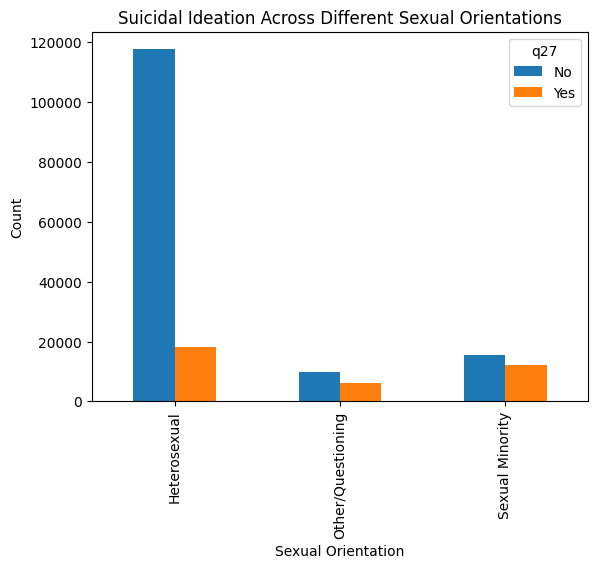

In [247]:
filtered.groupby(["sexid2", "q27"]).size().unstack().plot(kind="bar")
plt.title("Suicidal Ideation Across Different Sexual Orientations")
plt.ylabel("Count")
plt.xlabel("Sexual Orientation")
plt.show()

### Bar chart Interpretation

This plot shows the count of participants response to q27 (if they ever had suicidal ideation) and their corresponding sexual orientation. There is about 7x more participants that identify as heterosexual than sexual minority, but the difference between the those that had suicidal ideation and those that didn't for the heterosexual group is much larger than that for the sexual minority group. In other words, the proportion of those who said 'no' to q27 in the sexual minority group is much lower than the heterosexual group, meaning more participants in this group tend to have suicidal ideation. A similar pattern is seen with those that identified as 'Other/Questioning'.

### Inferential Statistics

In [248]:
geo_filtered = geo_merged.drop(columns=['ALAND', 'AWATER', 'TotalCount',
                                        '%MissingQ27Data', '%MissingAgeData',                                        '%MissingSexData', '%Missingsexid2',
                                        '%MissingRaceData'])

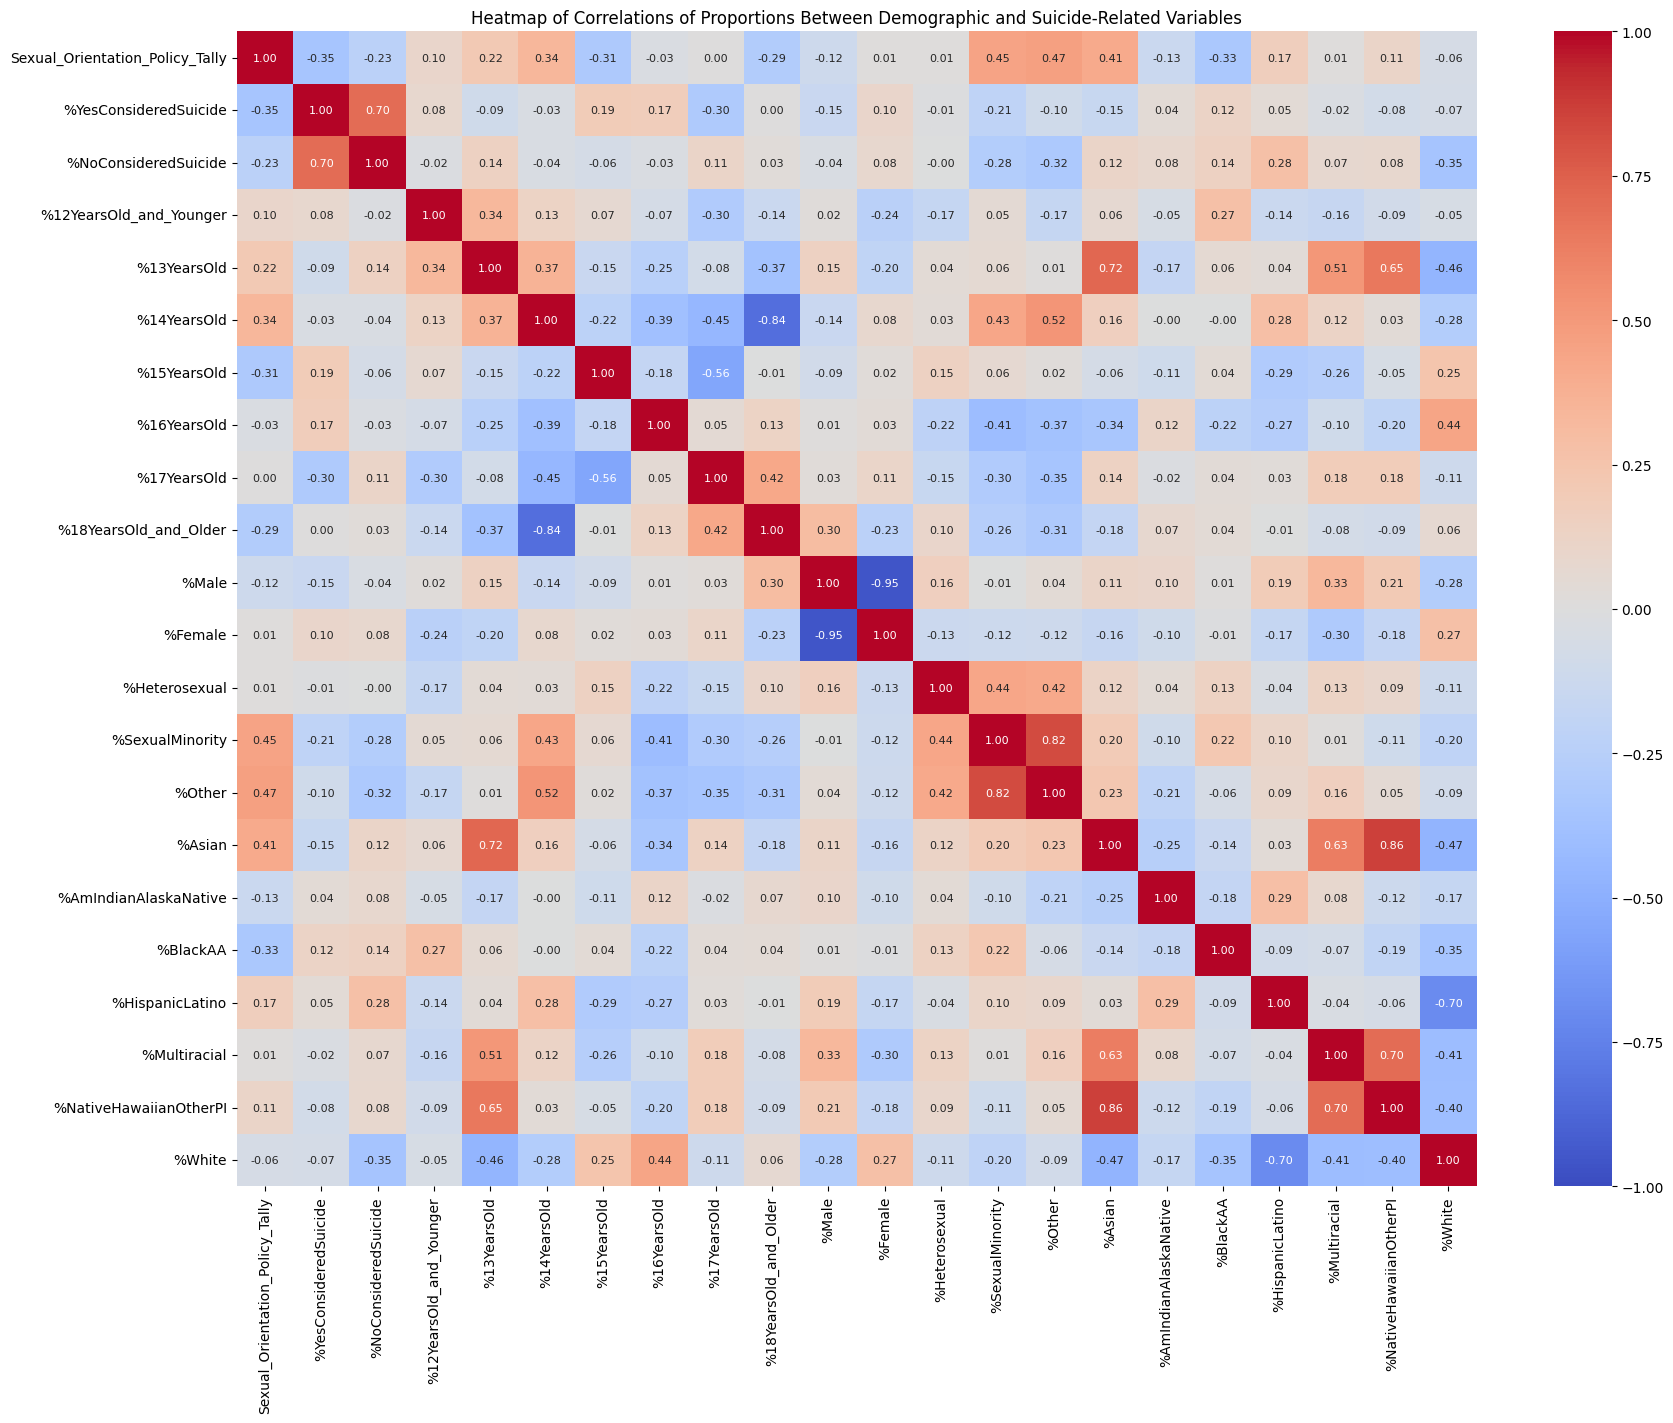

In [249]:
plt.figure(figsize = (20,15))
sns.heatmap(geo_filtered.corr(numeric_only=True), cmap='coolwarm',
            vmax=1,vmin=-1,annot=True, fmt=".2f", annot_kws={"size": 8})
plt.title("Heatmap of Correlations of Proportions Between Demographic and Suicide-Related Variables")
plt.show()

### Heatmap Interpretation

Looking at the heatmap, we can see that there are a few highly correlated values. We see highly positive correlated values in the variables %NativeHawaiianOtherPI and %Asian (.86), which makes sense as states with a higher percentage of Asian residents also tend to have a higher percentage of Native Hawaiian or Other Pacific Islander residents. We also see a highly positive correlated value in variables %Other and %SexualMinority (.82). This also makes sense as they are both closely related in terms of classification. Interestingly though, we see a fairly highly correlated positive value between %YesConsideredSuicide and %NoConsideredSuicide (.7). This does cause an area of concern as we would expect these values to be highly correlated, but in the negative direction. This could be seen due to the fact that we did remove null values within our percent proportion calculations.

We see highly negatively correlated values in variables %Male and %Female (-.95), %White and %HispanicLatino (-.70), and %18YearsOld_and_Older and %14YearsOld (-.84). These all make sense as these are all considered opposites of each other.

### Inferential Statistics

We are conducting a chi-square analysis here to look at the significance of suicidal ideation between sexual minorities and heterosexual youth. The chi-square analysis would identify whether there are difference between these two groups and how significant the difference is. Determining this would help understand possible patterns with mental health such as whether location or protective policy has an effect on the results seen.

**Null Hypothesis ($\mathbf{H_0}$)**: There is no statistical association (or no relationship) for suicidal ideation among sexual minorities or heterosexual youth.

**Alternate Hypothesis ($\mathbf{H_a}$)**: There is a statistical association (or a relationship) for suicidal ideation among sexual minorities or heterosexual youth.

In [250]:
filtered_clean = filtered[(filtered['q27'].isin(
    ['Yes', 'No'])) &
    (filtered['sexid2'].notna())].copy()

print(f"Cleaned dataset size: {len(filtered_clean):,} rows")
print(f"Original dataset: {len(filtered):,} rows")

Cleaned dataset size: 179,835 rows
Original dataset: 243,844 rows


In [251]:
sexual_minority_contingency = pd.crosstab(
    filtered_clean['q27'],
    filtered_clean['sexid2'],
    margins=True,
    margins_name='Total'
)
print(sexual_minority_contingency)

sexid2  Heterosexual  Other/Questioning  Sexual Minority   Total
q27                                                             
No            117682               9931            15453  143066
Yes            18275               6279            12215   36769
Total         135957              16210            27668  179835


In [252]:
chi2_stat, p_value, dof, expected = chi2_contingency(sexual_minority_contingency)
print(f"Chi-square statistic (χ²): {chi2_stat:.4f}")
print(f"P-value: {p_value:.2e}" if p_value < 0.001
      else f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

alpha = 0.05
critical_value = chi2.ppf(1 - alpha, dof)
print(f"Significance level (α): {alpha}")
print(f"Critical value: {critical_value:.4f}")

Chi-square statistic (χ²): 16990.6652
P-value: 0.00e+00
Degrees of freedom: 6
Significance level (α): 0.05
Critical value: 12.5916


### Chi-Square Analysis Interpretations

Comparing the p-value of 0.00 to the alpha value of .05, we can reject the null hypothesis and accept the alternative hypothesis that there is a more statistically significant association (or a relationship) that sexual minority youth that considered suicide (q27) compared to heterosexual youth.

## 2. Do harmful/protective LGBTQIA+ policies impact youth suicidal ideation?

### Descriptive Statistics

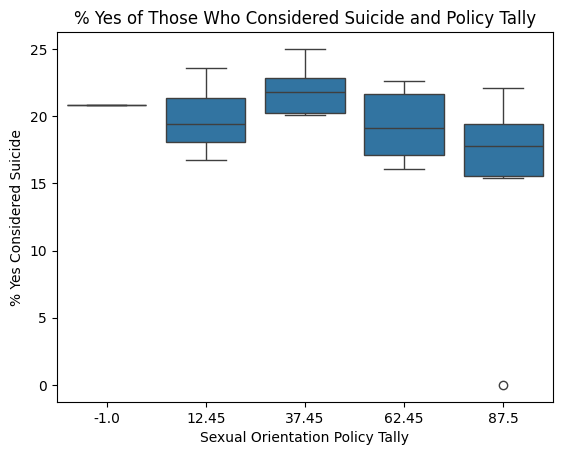

In [253]:
# Create boxplot showing stats between the different policy groups and the percent of people with suicidal ideation

sns.boxplot(x="Sexual_Orientation_Policy_Tally", y="%YesConsideredSuicide", data=geo_merged)
plt.title("% Yes of Those Who Considered Suicide and Policy Tally")
plt.ylabel("% Yes Considered Suicide")
plt.xlabel("Sexual Orientation Policy Tally")
plt.show()

### Boxplot Interpretation

This figure shows the relationship between state-level LGBTQ+ policy protections and the percentage of youth who reported considering suicide (YRBS Q27). States with fewer protective policies exhibit higher median rates of suicidal ideation. In contrast, states with more comprehensive protections tend to have lower rates. The overall pattern suggests that a more affirming policy climate may be associated with improved mental health outcomes among seuxal minority youth populations.

### Inferential Statistics

We are choosing to do a chi-square analysis here due to the fact that q27 and Sexual_Orientation_Policy_Tallyare both categorical variables. The chi-square analysis would help show if there is a significant association between harmful/protective policy and suicidal ideation, with a higher Sexual_Orientation_Policy_Tally value indicating more protective policies and a lower Sexual_Orientation_Policy_tally value indicating more harmful policies.

**Null Hypothesis ($\mathbf{H_0}$)**: There is no statistical association (or no relationship) between the state's Sexual_Orientation_Policy_Tally and the prevalence of youth considered suicide (q27).

**Alternate Hypothesis ($\mathbf{H_a}$)**: There is a statistical association (or a relationship) between the state's Sexual_Orientation_Policy_Tally and the prevalence of youth that considered suicide (q27).

In [254]:
subpolicy = policy[['V001', 'V005_MP']]
subpolicy = subpolicy.rename(columns={'V001':'sitecode',
                            'V005_MP':'Sexual_Orientation_Policy_Tally'})

In [255]:
subpolicy_suicide = filtered.merge(subpolicy, on='sitecode')
subpolicy_suicide

,sitecode,year,age,sex,race7,sexid2,q27,Sexual_Orientation_Policy_Tally
0,Alabama,2021,12 years old or younger,NaN,NaN,NaN,Yes,-1.00
1,Alabama,2021,14 years old,NaN,NaN,NaN,NaN,-1.00
2,Alabama,2021,14 years old,NaN,Hispanic/Latino,NaN,NaN,-1.00
3,Alabama,2021,15 years old,NaN,NaN,NaN,NaN,-1.00
4,Alabama,2021,17 years old,NaN,NaN,NaN,NaN,-1.00
...,...,...,...,...,...,...,...,...
243839,Wisconsin,2023,18 years old or older,Female,White,Heterosexual,No,62.45
243840,Wisconsin,2023,18 years old or older,Female,White,Heterosexual,No,62.45
243841,Wisconsin,2023,18 years old or older,Female,White,Heterosexual,No,62.45
243842,Wisconsin,2023,18 years old or older,Female,White,Other/Questioning,No,62.45


In [256]:
subpolicy_suicide_clean = subpolicy_suicide[(subpolicy_suicide['q27'].isin(
    ['Yes', 'No'])) &
    (subpolicy_suicide['Sexual_Orientation_Policy_Tally'].notna())].copy()

print(f"Cleaned dataset size: {len(subpolicy_suicide_clean):,} rows")
print(f"Original dataset: {len(subpolicy_suicide):,} rows")

Cleaned dataset size: 204,896 rows
Original dataset: 243,844 rows


In [257]:
subpolicy_contingency = pd.crosstab(
    subpolicy_suicide_clean['q27'],
    subpolicy_suicide_clean['Sexual_Orientation_Policy_Tally'],
    margins=True,
    margins_name='Total'
)
print(subpolicy_contingency)

Sexual_Orientation_Policy_Tally  -1.0   12.45   37.45   62.45   87.5   Total
q27                                                                         
No                               2113   32038   17826   98118  12996  163091
Yes                               580    8161    5168   24934   2962   41805
Total                            2693   40199   22994  123052  15958  204896


In [258]:
chi2_stat, p_value, dof, expected = chi2_contingency(subpolicy_contingency)
print(f"Chi-square statistic (χ²): {chi2_stat:.4f}")
print(f"p-value: {p_value:.2e}" if p_value < 0.001
      else f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

alpha = 0.05
critical_value = chi2.ppf(1 - alpha, dof)
print(f"Significance level (α): {alpha}")
print(f"Critical value: {critical_value:.4f}")

Chi-square statistic (χ²): 98.0172
p-value: 1.36e-16
Degrees of freedom: 10
Significance level (α): 0.05
Critical value: 18.3070


### Chi-Square Analysis Interpretations

Comparing the p-value of 1.36e-16 to the alpha value of .05, we can reject the null hypothesis and accept the alternative hypothesis that there is a statistically significant association (or a relationship) between the state's Sexual_Orientation_Policy_Tally and the prevalence of youth that considered suicide (q27).

## 3. How do state-level policy environments and geographic location influence suicidal ideation among sexual minority youth?

In [259]:
# View columns of merged geospatial data
geo_merged.columns

Index(['STATEFP', 'STATENS', 'AFFGEOID', 'GEOID', 'STUSPS', 'NAME', 'LSAD',
       'ALAND', 'AWATER', 'geometry', 'Sexual_Orientation_Policy_Tally',
       'TotalCount', '%MissingQ27Data', '%YesConsideredSuicide',
       '%NoConsideredSuicide', '%MissingAgeData', '%12YearsOld_and_Younger',
       '%13YearsOld', '%14YearsOld', '%15YearsOld', '%16YearsOld',
       '%17YearsOld', '%18YearsOld_and_Older', '%MissingSexData', '%Male',
       '%Female', '%Missingsexid2', '%Heterosexual', '%SexualMinority',
       '%Other', '%MissingRaceData', '%Asian', '%AmIndianAlaskaNative',
       '%BlackAA', '%HispanicLatino', '%Multiracial', '%NativeHawaiianOtherPI',
       '%White'],
      dtype='object')

In [260]:
# View summary statistics of merged geospatial data
geo_merged.describe()

,ALAND,AWATER,Sexual_Orientation_Policy_Tally,TotalCount,%MissingQ27Data,%YesConsideredSuicide,%NoConsideredSuicide,%MissingAgeData,%12YearsOld_and_Younger,%13YearsOld,...,%SexualMinority,%Other,%MissingRaceData,%Asian,%AmIndianAlaskaNative,%BlackAA,%HispanicLatino,%Multiracial,%NativeHawaiianOtherPI,%White
count,5.200000e+01,5.200000e+01,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,...,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,1.761537e+11,1.352032e+10,43.680000,7581.166667,5.126667,19.106667,75.776667,0.180000,0.343333,0.326667,...,13.833333,8.036667,2.076667,4.313333,1.873333,11.396667,23.740000,5.496667,1.466667,49.616667
std,2.207288e+11,3.645661e+10,31.334697,14297.528829,17.951427,4.370428,14.621092,0.142393,0.259553,0.255874,...,2.380573,1.586469,1.252221,4.323451,2.581624,10.545484,14.673636,2.859646,5.648029,20.014755
min,1.583162e+08,1.870979e+07,-1.000000,1036.000000,0.300000,0.000000,0.000000,0.000000,0.100000,0.000000,...,6.300000,3.200000,0.600000,0.800000,0.100000,0.900000,5.500000,1.700000,0.100000,7.500000
25%,7.938265e+10,1.747836e+09,12.450000,1806.500000,1.300000,17.825000,76.150000,0.100000,0.200000,0.200000,...,13.250000,7.525000,1.025000,2.050000,0.625000,4.125000,14.400000,4.200000,0.200000,34.650000
50%,1.368118e+11,3.890769e+09,37.450000,3312.000000,1.750000,19.900000,78.050000,0.100000,0.300000,0.200000,...,14.150000,8.350000,2.000000,3.350000,0.950000,8.500000,19.900000,4.700000,0.300000,49.300000
75%,2.076220e+11,1.064235e+10,62.450000,4951.750000,2.400000,21.800000,81.050000,0.200000,0.400000,0.400000,...,15.275000,9.025000,2.750000,4.725000,1.600000,13.950000,28.100000,5.900000,0.475000,67.900000
max,1.478944e+12,2.453777e+11,87.500000,73291.000000,100.000000,25.000000,83.900000,0.700000,1.300000,1.200000,...,17.400000,10.600000,5.200000,24.000000,12.100000,50.400000,62.800000,16.000000,31.300000,81.800000


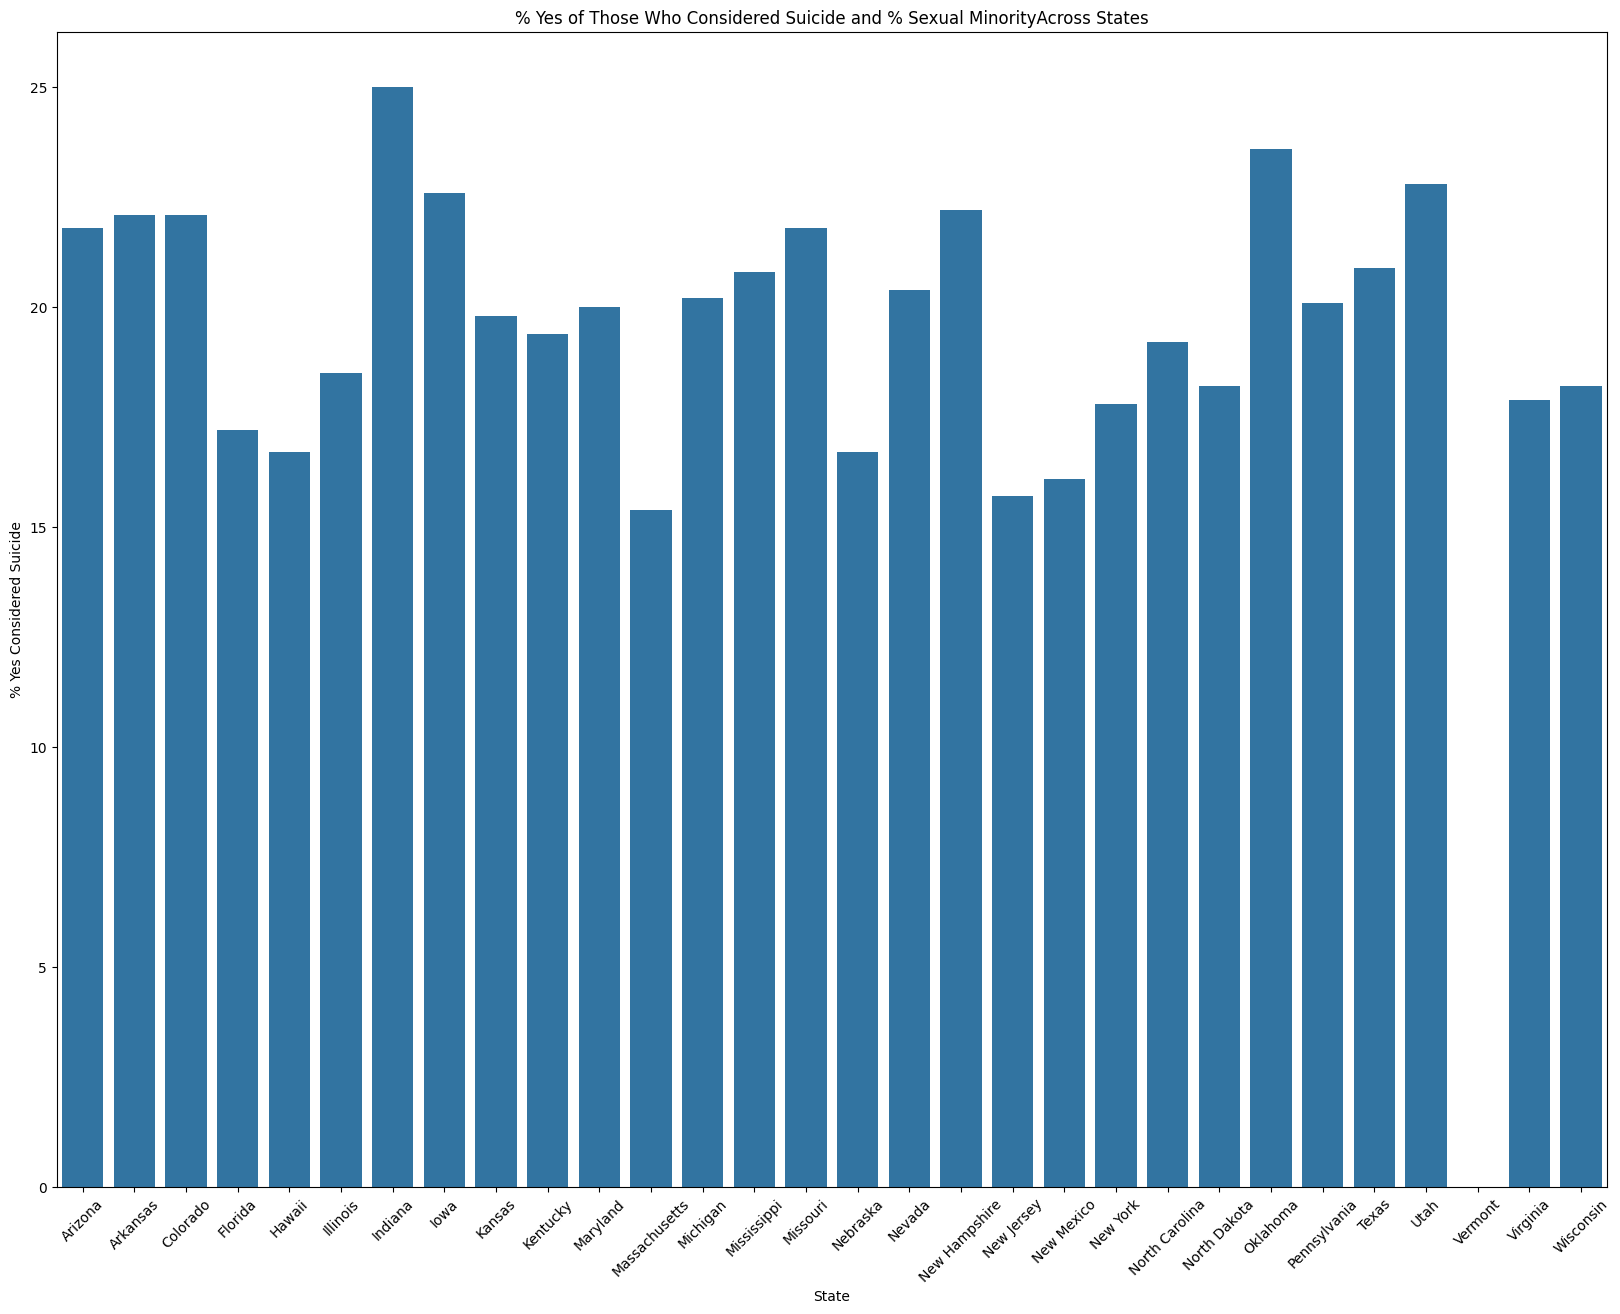

In [261]:
plt.figure(figsize = (20,15))
sns.barplot(x="NAME", y="%YesConsideredSuicide", data=policy_shape_concat)
plt.title("% Yes of Those Who Considered Suicide and % Sexual MinorityAcross States")
plt.xticks(rotation=45)
plt.ylabel("% Yes Considered Suicide")
plt.xlabel("State")
plt.show()

### Bar Chart Interpretation

Looking at this bar chat, we can see that the %SexualMinority persons across states that have considered suicide is above 15%. Vermont is the only exception, where they either have no data for this, or no one has considered suicide. With this finding though, it does cause for potential deeper analysis into Vermont and their policies or the data itself to see if there are any gaps.

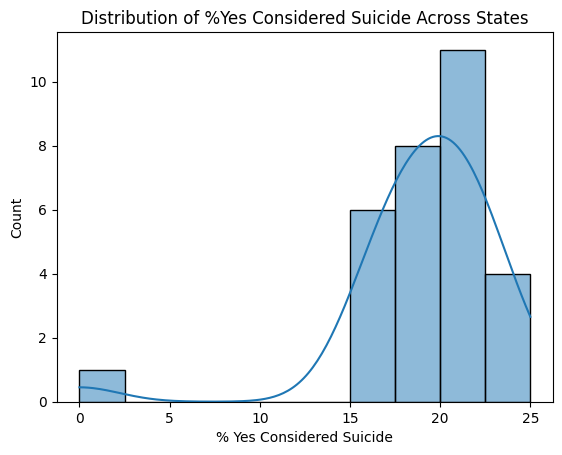

In [262]:
# Visualize the distribution of %YesConsideredSuicide
sns.histplot(data=geo_merged, x="%YesConsideredSuicide", kde=True)
plt.title("Distribution of %Yes Considered Suicide Across States")
plt.xlabel("% Yes Considered Suicide")
plt.ylabel("Count")
plt.show()

### Histogram Interpretation

This histogram of %YesConsideredSuicide across states shows us a unimodal distribution that is skewed to the left, with an extreme outlier on the left. This outlier can be explained by the bar chart above, where we saw Vermont without any counts of %YesConsideredSuicide. Also shown by the bar chart above, we saw that every state (other than Vermont) had a minimum %YesConsideredSuicide of 15%, with a maximum of 25%. The histogram shows us that the center of the unimodal peak is around 20%, with most counts of %YesConsideredSuicide sitting around 20-22.5%.

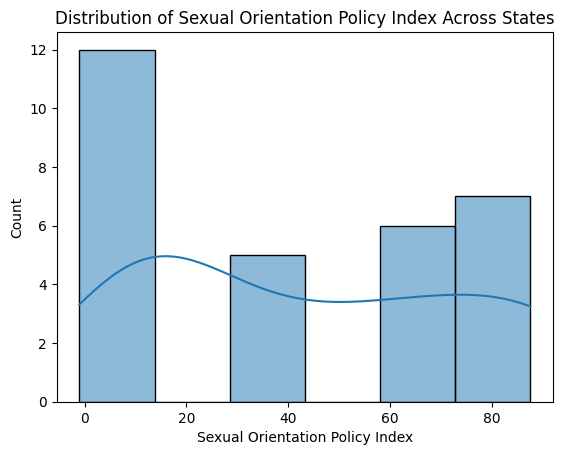

In [263]:
# Visualize the distribution of Sexual Orientation Policy Index
sns.histplot(data=geo_merged, x="Sexual_Orientation_Policy_Tally", kde=True)
plt.title("Distribution of Sexual Orientation Policy Index Across States")
plt.xlabel("Sexual Orientation Policy Index")
plt.ylabel("Count")
plt.show()


### Distribution Interpretation

This distribution indicates that LGBTQ+ policy environments across U.S. states are highly polarized. Most states fall either into the category of having few protections for sexual minorities or many protections, with relatively few in between. This likely reflects broader political and regional divides in how states approach LGBTQ+ rights and protections.

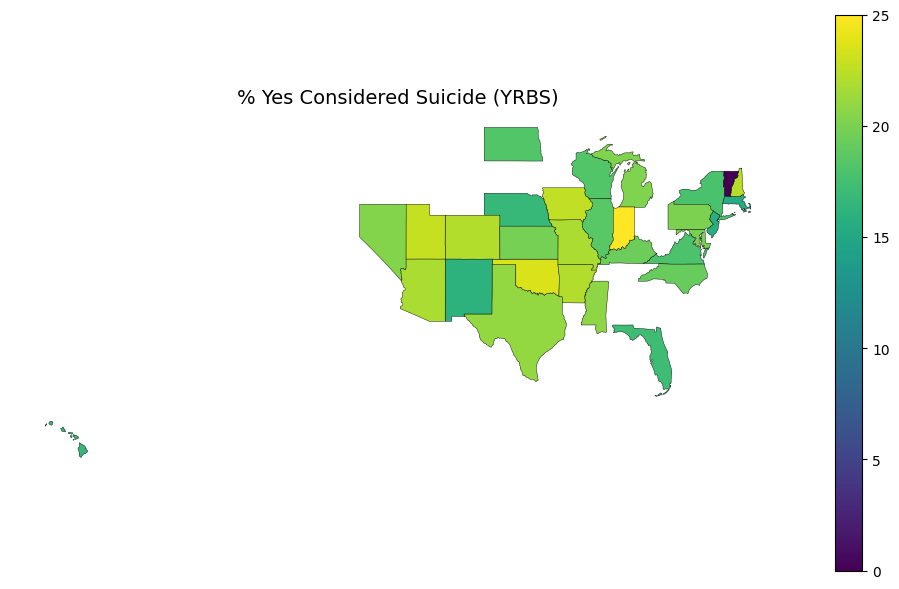

In [264]:
# Create a copy of the GeoDataFrame
g = geo_merged.copy()            # GeoDataFrame with a 'geometry' column

# Create a figure and axis for the plot to see distribution of youth considering suicide

fig, ax = plt.subplots(figsize=(10,6))
g.plot(
    column="%YesConsideredSuicide",
    cmap="viridis",
    linewidth=0.3,
    edgecolor="black",
    legend=True,
    ax=ax,
)
ax.set_title("% Yes Considered Suicide (YRBS)", color='black', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("considered_suicide.png")
plt.show()

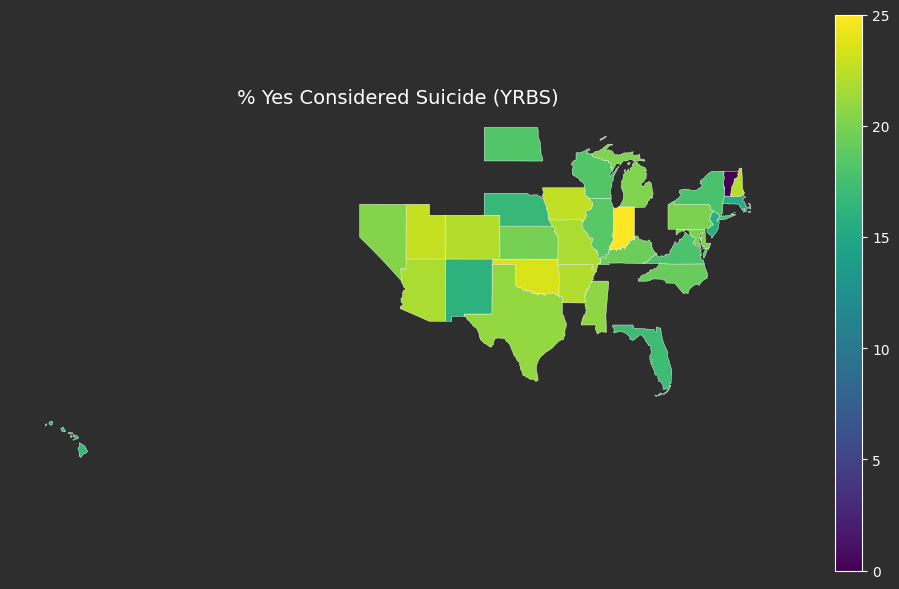

In [265]:
# Create a copy of the GeoDataFrame
g = geo_merged.copy()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#2E2E2E')

g.plot(
    column="%YesConsideredSuicide",
    cmap="viridis",
    linewidth=0.3,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title("% Yes Considered Suicide (YRBS)", color='white', fontsize=14)
ax.set_axis_off()

# Colorbar Axis
if len(fig.axes) > 1:
    cb_ax = fig.axes[1]
    cb_ax.tick_params(axis='y', colors='white', labelsize=10)
    cb_ax.spines['outline'].set_edgecolor('white')

plt.tight_layout()

# Save with transparency
plt.savefig("considered_suicide_dark.png", dpi=300, transparent=True)

plt.show()

### Chloropeth Map Interpretation

This figure shows state-level differences in the percentage of youth reporting suicidal ideation on the YRBS. The map suggests that suicidal ideation is not uniformly distributed across the United States. States in certain regions—particularly parts of the Northeast and South tend to report higher rates of youth considering suicide, while several western states report comparatively lower rates. These patterns highlight the importance of considering geographic and policy context when developing mental health interventions and prevention strategies.

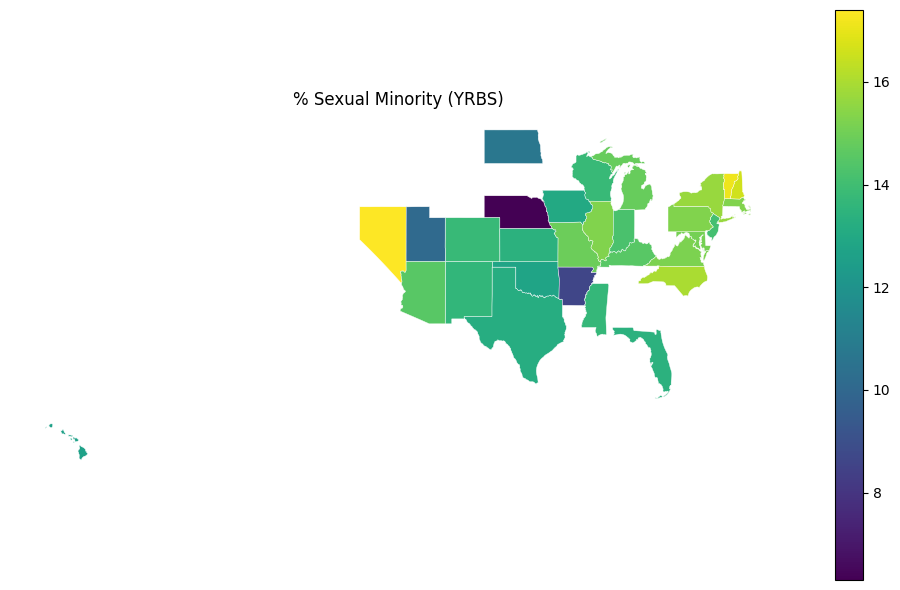

In [266]:
# plot to see distribution of youth that are sexual minority

fig, ax = plt.subplots(figsize=(10,6))
g.plot(
    column="%SexualMinority",
    cmap="viridis",
    linewidth=0.3,
    edgecolor="white",
    legend=True,
    ax=ax,
)
ax.set_title("% Sexual Minority (YRBS)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Chloropeth Map Interpretation

This figure shows the state-level distribution of youth identifying as sexual minorities, based on YRBS data. States in the Northeast and West tend to report higher percentages of sexual minority youth, whereas many central and southern states report lower percentages. One possible explanation of this could be that states with less social acceptance, such as the south, may have youth underreporting sexual minority status. 

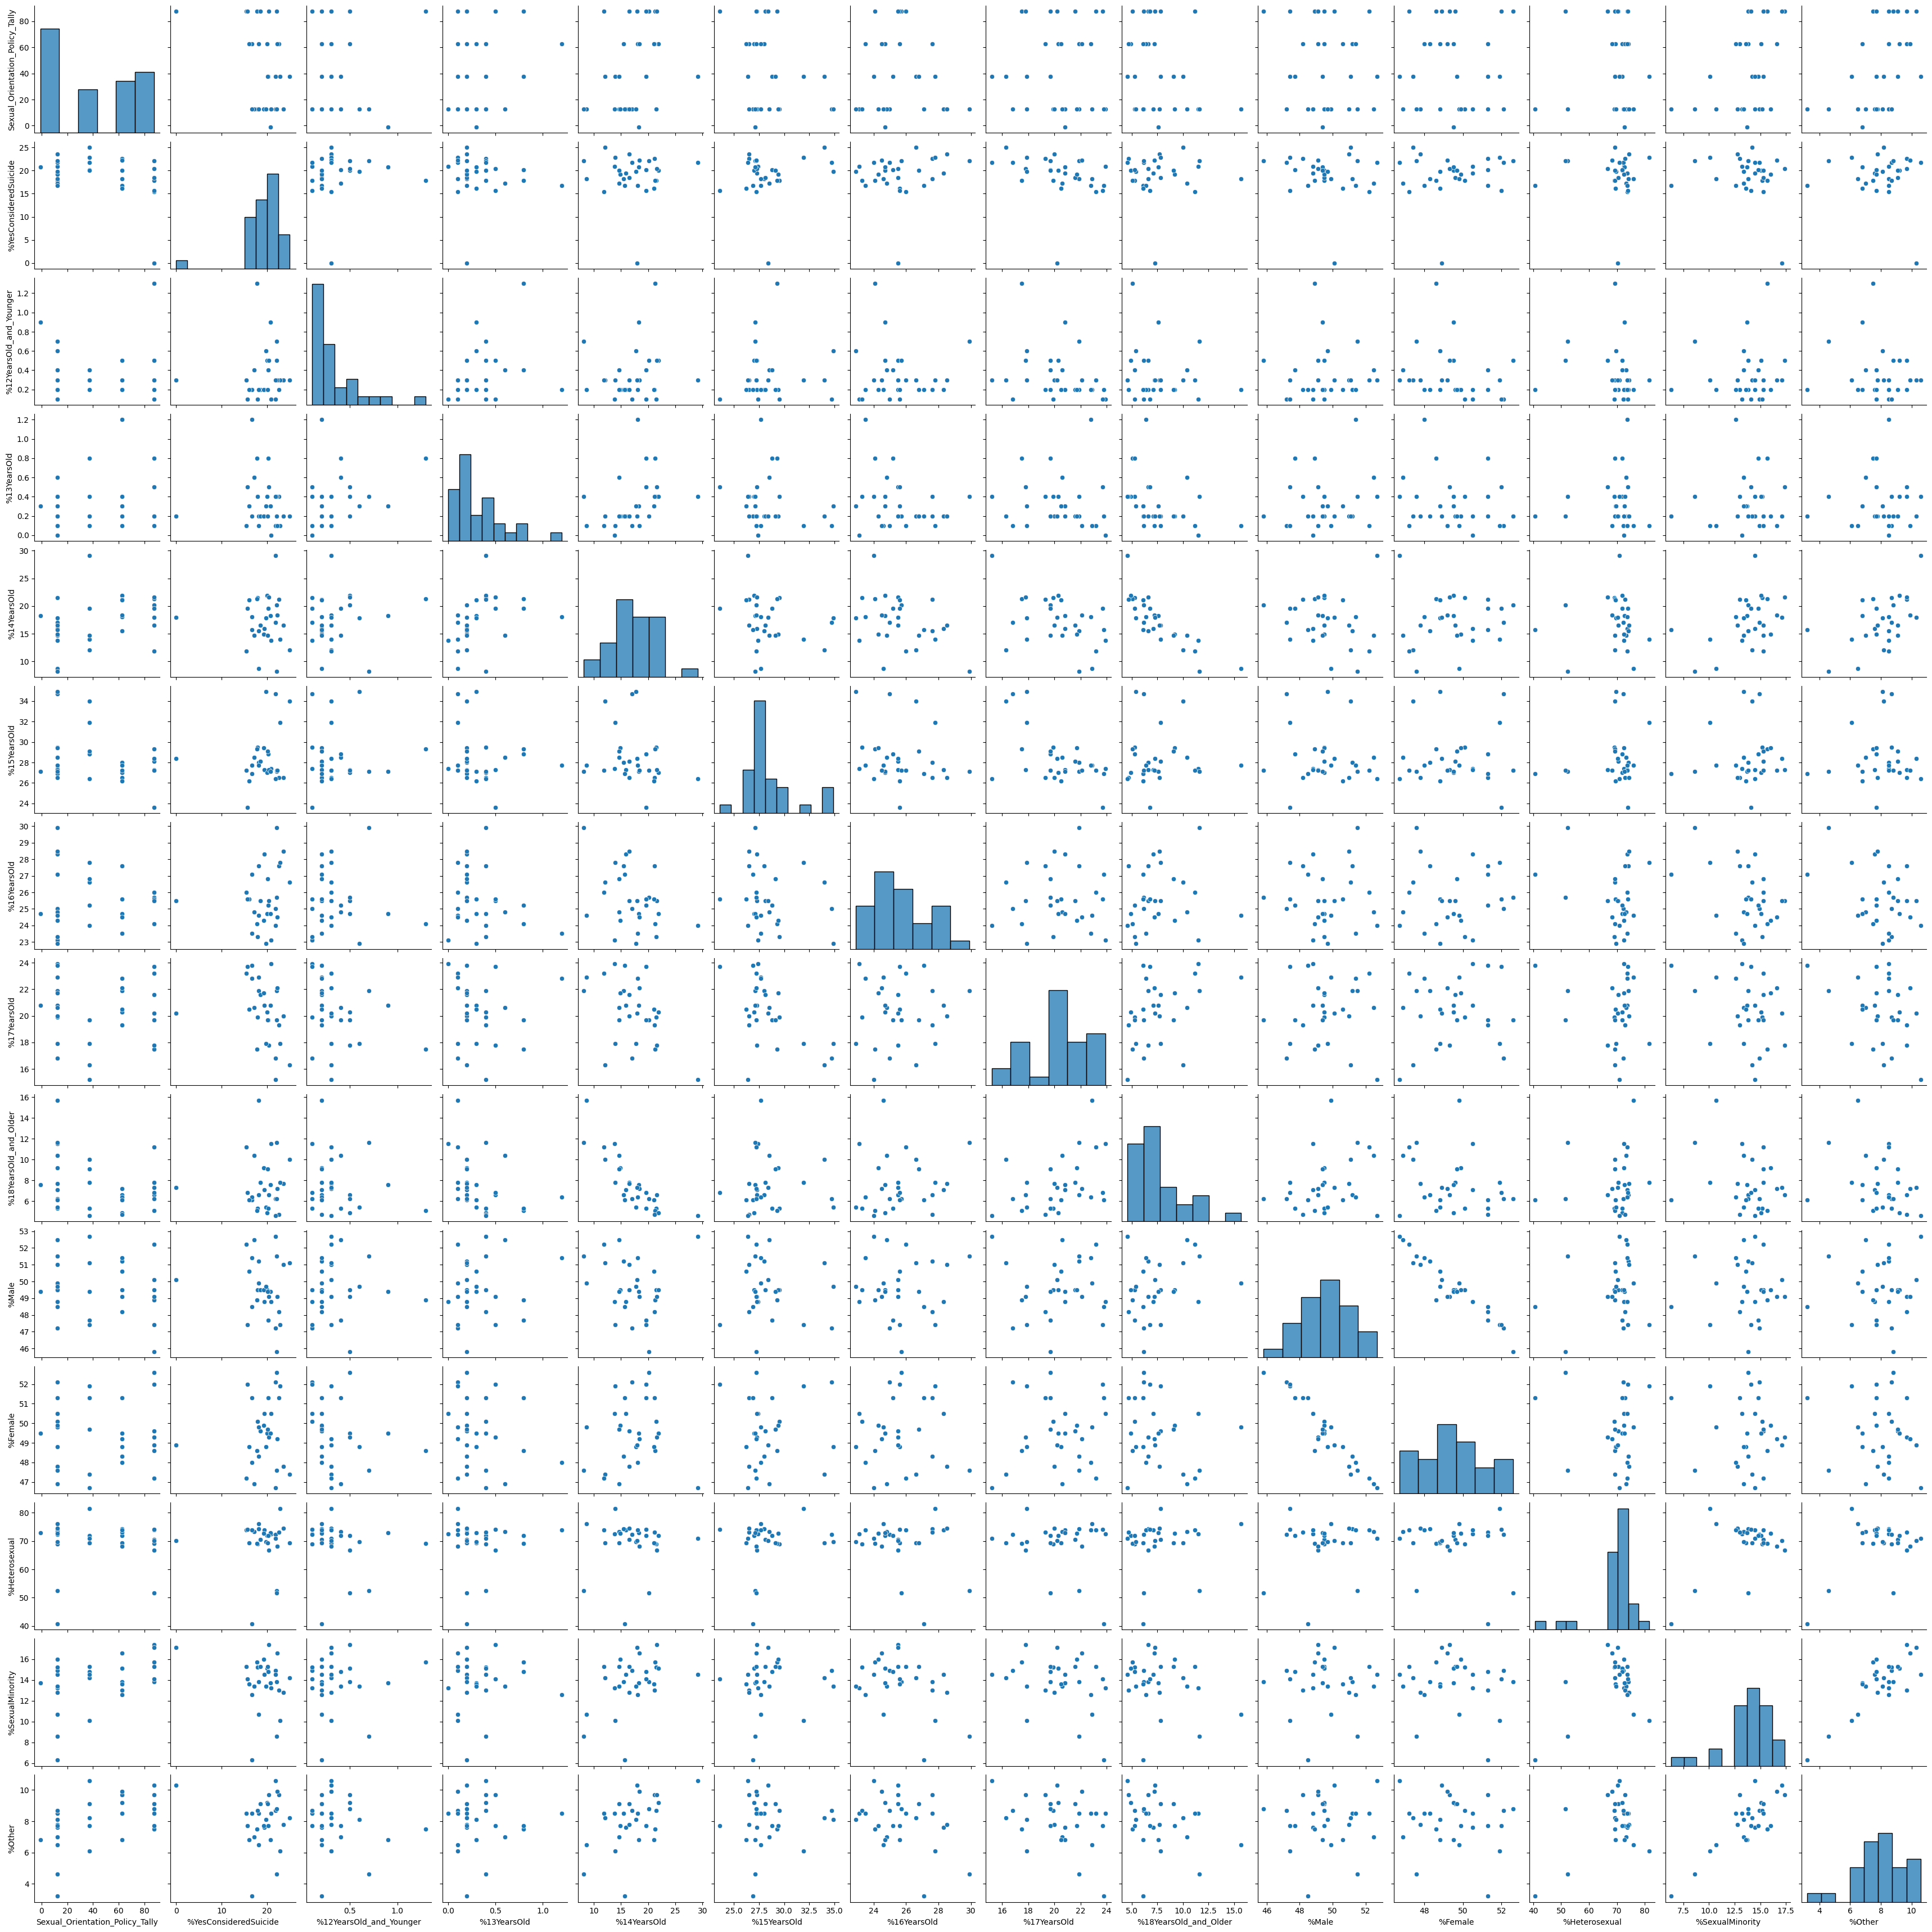

In [267]:
# Create a pair plot with columns of interest to see overview of variable relations
sns.pairplot(geo_merged, vars = ['Sexual_Orientation_Policy_Tally', '%YesConsideredSuicide',
       '%12YearsOld_and_Younger',
       '%13YearsOld', '%14YearsOld', '%15YearsOld', '%16YearsOld',
       '%17YearsOld', '%18YearsOld_and_Older', '%Male',
       '%Female', '%Heterosexual', '%SexualMinority',
       '%Other'])
plt.show()

### Pair Plot Interpretation

The pairplot displays the correlations of every variable within the dataframe against each other. From first glance we are able to identify basic relationships between some variables to get a sense of how they affect each other. For example, '%SexualMinority' and '%Other' have an apparent positve and strong relationship, as the value for one variable increases, so does the value for the other variable. Because this table shows correlations between every single variable, there are some relationships that do not show any type of relationship. For example, '%17YearsOld' and '%16YearsOld' show no identifiable relationship but this makes sense as you cannot be two different ages at the same time. Similarly, for variables that are categorical there is no identifiable relationship since the plot will have dots on one side of the plot. Overall, this pairplot shows there is some influence with '%YesConsideredSuicide' and the different propotion of ages, which we can look into.

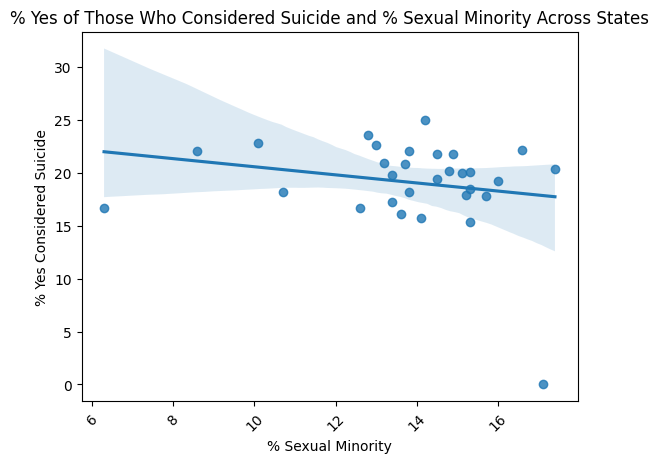

In [268]:
# Create a regression plot to visualize relationship between percentage of sexual minorities and those who had suicidal ideation

sns.regplot(x="%SexualMinority", y="%YesConsideredSuicide", data=geo_merged)
plt.title("% Yes of Those Who Considered Suicide and % Sexual Minority Across States")
plt.xticks(rotation=45)
plt.ylabel("% Yes Considered Suicide")
plt.xlabel("% Sexual Minority")
plt.show()

### Regression Plot Interpretation

The regression plot visualizing the relationship between a state's %SexualMinority population and its aggregate %YesConsideredSuicide rate shows an unexpected, slightly negative trend line. This downward slope is highly suspicious and is most likely an artifact caused by a single, high-leverage outlier located on the right side of the plot. This outlier represents a state with a high proportion of sexual minority youth but a near-zero suicide rate, which strongly pulls the line away from the cluster of other states. Consequently, the true, likely positive underlying relationship between the size of the high-risk population and the aggregate suicide ideation rate is obscured, necessitating that this outlier state be either removed or analyzed separately in the final multivariate models.

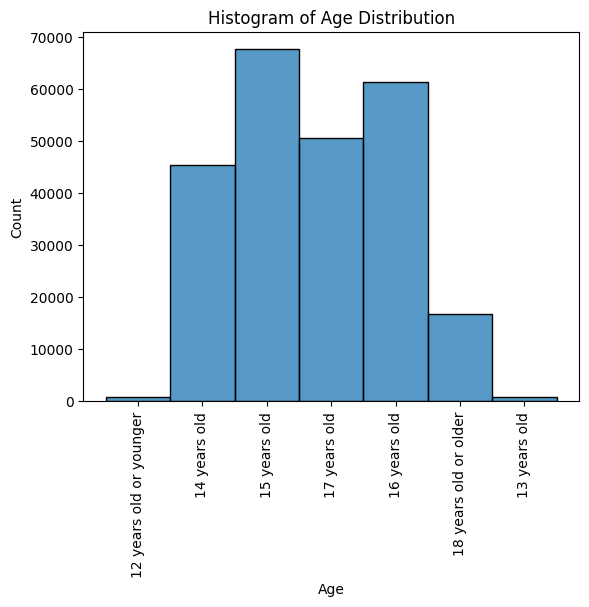

In [269]:
# Create a histogram to visualize the distribution of age
age_hist = sns.histplot(x="age", data=copy)

_ = plt.xticks(rotation=90)
plt.xlabel("Age")
age_hist.set_title("Histogram of Age Distribution")
plt.show()


### Histogram Interpretation

This histogram of the age distribution shows us a unimodal distribution that is overall, normal. Most of the observations identify as 15 years old, with the second most being 16 years old. The age distribution shows what age groups are responding to these prompts, which can give us insight onto which ages are most at risk for sucidial ideation. 

## Inferential Statistics

In [270]:
df = filtered.copy()

# Create binary outcome variable
df["q27_binary"] = df["q27"].map({"Yes": 1, "No": 0})

# Drop rows with missing values
df = df.dropna(subset=["q27_binary", "sexid2", "sex", "age"])

# Ensure categorical variables are treated as such
df["sexid2"] = pd.Categorical(df["sexid2"], 
                              categories=["Heterosexual", "Sexual Minority", "Other/Questioning"])
df["sex"]    = pd.Categorical(df["sex"], categories=["Male", "Female"])
df["age"]    = pd.Categorical(df["age"], categories=[
    "12 years old or younger","13 years old","14 years old","15 years old",
    "16 years old","17 years old","18 years old or older"
])

results = []
for site, data in df.groupby("sitecode"):
    if len(data) < 50: 
        continue
    if data["q27_binary"].nunique() < 2:
        continue

    try:
        model = smf.glm(
            "q27_binary ~ C(sexid2, Treatment(reference='Heterosexual'))" 
            " + C(age, Treatment(reference='15 years old'))"
            " + C(sex, Treatment(reference='Male'))",
            data=data, family=sm.families.Binomial()
        ).fit() # create fit for heterosexual male 

        # coefficient for Sexual Minority vs Heterosexual
        key = "C(sexid2, Treatment(reference='Heterosexual'))[T.Sexual Minority]"
        coef = model.params.get(key, np.nan)
        pval = model.pvalues.get(key, np.nan)
        results.append({"sitecode": site, "estimate": coef, "p_value": pval})

    except PerfectSeparationError:
        results.append({"sitecode": site, "estimate": np.nan, "p_value": np.nan})

state_results = pd.DataFrame(results)
# Compute odds ratios
state_results["odds_ratio"] = np.exp(state_results["estimate"])


The code above is to run a logistic regression since our outcome variable is a categorical variable. Additionally, we added age and sex as covariates into this model since prior work has shown that there may be sex differences in suicidal ideation. Further, adolescence is a crucial time of development where mental disorders begin to emerge. By including these covariates, we aim to isolate the association between sexual minority identity and the likelihood of considering suicide across states.

In [271]:
state_results

,sitecode,estimate,p_value,odds_ratio
0,Arizona,1.614717,8.025823e-17,5.026465
1,Arkansas,1.214505,2.742146e-12,3.368626
2,Colorado,1.487501,4.033621e-11,4.426021
3,Florida,1.458237,3.438168e-46,4.298375
4,Hawaii,1.372086,1.585840e-82,3.943570
5,Illinois,1.335077,7.310758e-52,3.800288
6,Indiana,1.591533,2.287341e-28,4.911273
7,Iowa,1.555572,6.333248e-18,4.737796
8,Kansas,1.634816,3.735869e-20,5.128514
9,Kentucky,1.421491,4.692810e-43,4.143295


These results indicate a consistent and significant association between sexual minority identity and suicidal ideation across all analyzed states. Sexual minority youth are at a substantially higher risk - typically 3 to 6 times more likely - to have seriously considered suicide compared to their heterosexual peers. Although the magnitude varies by state, the relationship remains strong everywhere, emphasizing the widespread mental health disparities faced by sexual minority adolescents.

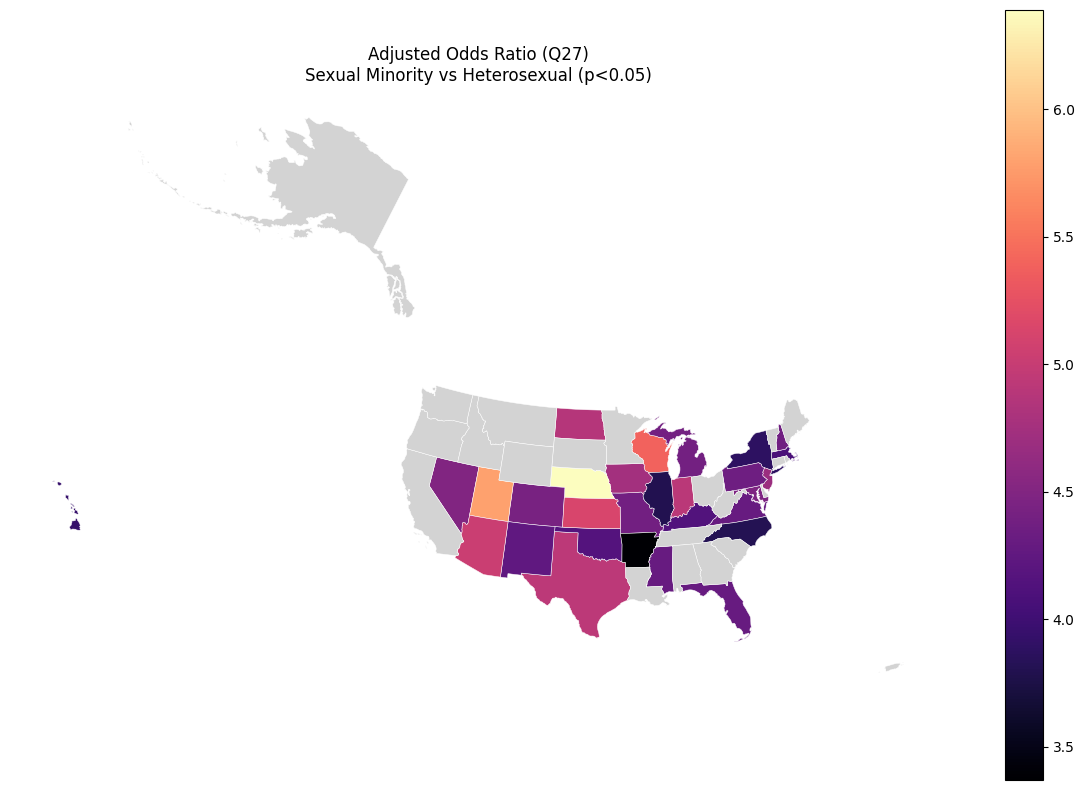

In [272]:
map_df = gdf.merge(state_results, left_on="NAME", right_on="sitecode", how="left")

# Show states with p < .05
map_df["or_sig"] = np.where(map_df["p_value"] < 0.05, map_df["odds_ratio"], np.nan)

# Project to Albers Equal Area
map_df = map_df.to_crs(5070)

ax = map_df.plot(
    column="or_sig", cmap="magma", legend=True,
    edgecolor="white", linewidth=0.35, figsize=(12,8),
    missing_kwds={"color": "lightgrey", "label": "No data"}
)
ax.set_title("Adjusted Odds Ratio (Q27)\nSexual Minority vs Heterosexual (p<0.05)")
ax.axis("off")

plt.tight_layout()
plt.savefig("choropleth_or_sig.png", dpi=300)
plt.show()

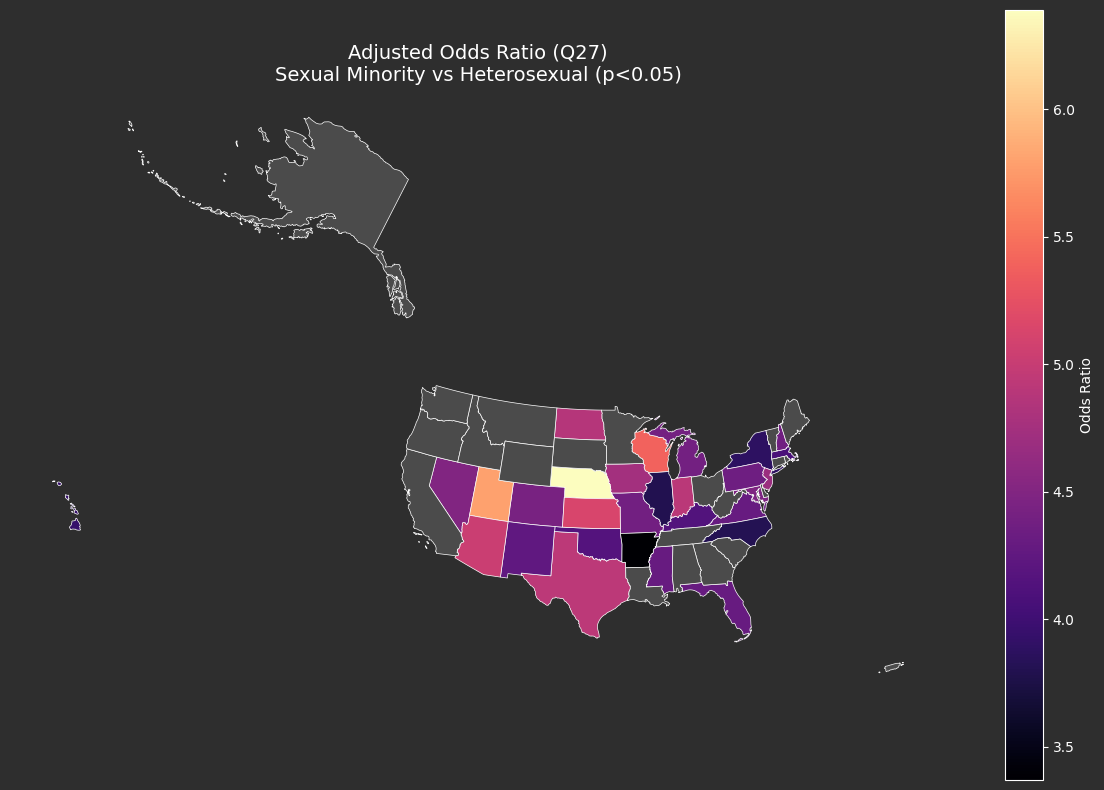

In [273]:
map_df = gdf.merge(state_results, left_on="NAME", right_on="sitecode", how="left")

# Show states with p < .05
map_df["or_sig"] = np.where(map_df["p_value"] < 0.05, map_df["odds_ratio"], np.nan)

# Project to Albers Equal Area 
map_df = map_df.to_crs(5070)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
fig.patch.set_facecolor('#2E2E2E')

map_df.plot(
    column="or_sig", 
    cmap="magma", 
    legend=True,
    edgecolor="white",  # White state borders
    linewidth=0.5,      # thicker lines for visibility
    ax=ax,
    missing_kwds={
        "color": "#4B4B4B",     # Dark grey for states with no data/not sig
        "label": "No Data / Not Sig"
    },
    legend_kwds={'label': "Odds Ratio"} # Label the colorbar
)

ax.set_title(
    "Adjusted Odds Ratio (Q27)\nSexual Minority vs Heterosexual (p<0.05)", 
    color='white', 
    fontsize=14
)
ax.axis("off")

if len(fig.axes) > 1:
    cb_ax = fig.axes[1] 
    cb_ax.tick_params(axis='y', colors='white') # white ticks for bar
    cb_ax.yaxis.label.set_color('white')
    cb_ax.spines['outline'].set_edgecolor('white')

plt.tight_layout()
plt.savefig("choropleth_or_sig_dark.png", dpi=300,transparent=True)
plt.show()

This figure displays the adjusted odds ratios of youth suicidal ideation (Q27) comparing sexual minority to heterosexual adolescents across U.S. states. Results indicate a consistent and significant disparity nationwide: sexual minority youth are between 3 to 6 times more likely to have seriously considered suicide, even after accounting for demographic factors such as age and sex. States with higher odds ratios (e.g., Nebraska, Utah, Wisconsin) may reflect regions where stigma, limited access to affirming care, or restrictive policy climates exacerbate mental health risks among LGBTQ+ youth.

In [274]:
# Add policy data to state results
state_results = state_results.merge(policy_filtered, left_on='sitecode', right_on='NAME', how='left')
state_results

,sitecode,estimate,p_value,odds_ratio,NAME,Sexual_Orientation_Policy_Tally
0,Arizona,1.614717,8.025823e-17,5.026465,Arizona,37.45
1,Arkansas,1.214505,2.742146e-12,3.368626,Arkansas,12.45
2,Colorado,1.487501,4.033621e-11,4.426021,Colorado,87.50
3,Florida,1.458237,3.438168e-46,4.298375,Florida,12.45
4,Hawaii,1.372086,1.585840e-82,3.943570,Hawaii,62.45
5,Illinois,1.335077,7.310758e-52,3.800288,Illinois,87.50
6,Indiana,1.591533,2.287341e-28,4.911273,Indiana,37.45
7,Iowa,1.555572,6.333248e-18,4.737796,Iowa,62.45
8,Kansas,1.634816,3.735869e-20,5.128514,Kansas,12.45
9,Kentucky,1.421491,4.692810e-43,4.143295,Kentucky,12.45


In [275]:
# Run a regression to see how policy affects the odds ratios across states
state_results["log_or"] = np.log(state_results["odds_ratio"])

policy_model = smf.ols("log_or ~ Sexual_Orientation_Policy_Tally", data=state_results).fit()
print(policy_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 log_or   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                 -0.019
Method:                 Least Squares   F-statistic:                    0.4657
Date:                Mon, 01 Dec 2025   Prob (F-statistic):              0.501
Time:                        23:04:39   Log-Likelihood:                 18.263
No. Observations:                  29   AIC:                            -32.53
Df Residuals:                      27   BIC:                            -29.79
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

This regression found no statistically significant relationship between state-level sexual orientation policy scores and the strength of the association between sexual minority status and suicidal ideation (β = -0.0006, p = 0.501). Although the direction of the effect was negative - suggesting that states with more protective LGBTQ+ policies may have slightly lower suicide risk disparities - the relationship was extremely weak and explained little of the variance (R² = 0.017).
These results suggest that policy context alone does not fully account for cross-state differences in suicidal ideation disparities between sexual minority and heterosexual youth.

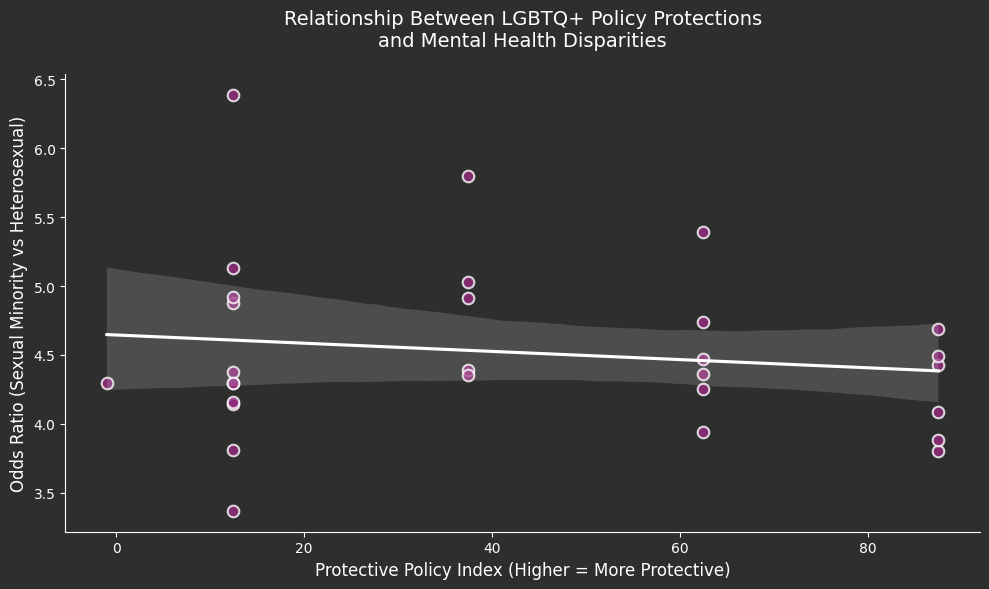

In [276]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#2E2E2E')
ax.set_facecolor('#2E2E2E')

sns.regplot(
    x="Sexual_Orientation_Policy_Tally",
    y="odds_ratio",
    data=state_results,
    ax=ax,
    marker="o",
    scatter_kws={"s": 70, "facecolors": "#952C80", "edgecolors": "white", "linewidths": 1.5},
    line_kws={"color": "white"}
)

ax.set_title("Relationship Between LGBTQ+ Policy Protections\nand Mental Health Disparities", color='white', fontsize=14, pad=20)
ax.set_xlabel("Protective Policy Index (Higher = More Protective)", color='white', fontsize=12)
ax.set_ylabel("Odds Ratio (Sexual Minority vs Heterosexual)", color='white', fontsize=12)

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("lin_reg_white_axis.png", dpi=300, transparent=True, bbox_inches='tight')
plt.show()

## Synthesis 
This project aimed to examine the relationship between state-level LGBTQIA+ policies and suicidal ideation among sexual minority youth. By linking indicators of policy protection or harm to mental health outcomes, this analysis explored how structural contexts shape disparities in youth mental health. Understanding these associations can inform more effective public health strategies and guide policy interventions aimed at reducing suicide risk among LGBTQIA+ populations.

To address this, we linked the CDC’s Youth Risk Behavior Surveillance System (YRBS) with state-level sexual orientation policy tallies and U.S. shapefiles to analyze and visualize state-specific mental health disparities. This combined dataset was critical because it allowed us to integrate individual-level health behavior data with structural and geographic variables, enabling a more comprehensive view of how policy context and location intersect to impact mental health outcomes. The merged dataset thus provided a foundation for both statistical modeling and geospatial visualization, helping to identify where disparities are most concentrated and how they may align with differing policy climates across the U.S. Our research focused on three key questions:

1. Are sexual minority youth at higher risk for suicidal ideation than heterosexual youth?
2. Do harmful or protective LGBTQIA+ policies impact youth suicidal ideation?
3. How do state-level policy environments and geography influence suicidal ideation among sexual minority youth?

A chi-square analysis revealed a highly significant relationship (χ² = 16,990.67, p < .001) between sexual identity and suicidal ideation, confirming that sexual minority youth were significantly more likely to report having considered suicide compared to heterosexual peers. This aligns with prior evidence of disproportionate mental health burdens among LGBTQ+ adolescents.

A boxplot visualization comparing the percentage of youth who considered suicide across levels of the Sexual Orientation Policy Tally showed a slight downward trend - states with higher (more protective) policy scores tended to have somewhat lower median percentages of suicidal ideation. However, the variation across groups remained substantial, and protective policy strength did not appear to fully mitigate risk.

A linear regression assessing the association between state policy tallies and odds ratios of suicidal ideation found no statistically significant relationship (β = -0.0006, p = 0.501, R² = 0.017). While the negative slope suggested that states with more protective policies may have slightly smaller disparities, the effect was minimal and not significant.

Collectively, these results suggest that although sexual minority youth face substantially elevated risks of suicidal ideation, state-level policy protections alone do not significantly explain variation in these disparities across the U.S. The persistence of high odds ratios, even in protective policy environments, indicates that broader social, familial, and institutional factors - such as stigma, gay straight alliance clubs in school, and access to affirming care - may play stronger roles in shaping mental health outcomes.

## Reflection

One of our biggest challenges at first was figuring out how to merge out different dataframes together, and deciding which columns were necessary for our future analysis. We had three different data frames (policy, shape, and YRBSS data). We calculated the midpoint of V005 in order to have a data point to be usable in our future analysis, and then dropped all of the other policy columns after. In order to have a better understanding of the proportions of different demographics present within our dataset for future graphical analysis, we created 5 temporary dataframes of q27 (suicidal ideation), age, sex, race, and sexid2 (sexual orientation). This was then merged with our three other main dataframes.

We then broke down our analysis question by question, focusing with our first question of 'Are sexual minority youth at higher risk for suicidal ideation than heterosexual youth?'. We wanted to see if there were any notable or apparent trends right off the bat, which is why we created the bar chart of counts of suicidal ideation vs sexual orientation. Not surprisingly, we found that heterosexuals were more likely to respond no to q27, and that sexual minorities or those that marked other/questioning had a much more balanced response. We also created a heatmap of the demographic proportions to see if there were any apparent trends there, where we did find some expected and unexpected trends. One trend that was unexpected was that the %YesConsideredSuicide and %NoConsideredSuicide had a correlation of .7, which is opposite of what we expected, which would be a strong negative correlation. This shows flaw in our data, which could be explained by the fact that we did do a calculation to find proportions where we did end up dropping null values. Potentially, if we did this heatmap again with the full dataset, we might find different results that could end up showing more accurate correlations.

The second question we wanted to explore was 'Do harmful/protective LGBTQIA+ policies impact youth suicidal ideation?'. This questions would help us understand how youth suicidal ideation varies across states with either less protective policies or more protective policies.

We first created a boxplot graph displaying the spread, skewness, and centers for the percentage of those who have considered suicide and the policy tally associated with their state. Since the value of policy tally varies, we want to see how the overview of youth who have considered suicide are spread, this would give indication if a lower tally score (or a less protective policy) is associated with higher rates of suicidal ideation. We looked at this graph to guide our analysis and statistical tests for this question.l

The next step was conducting a chi-square analysis and creating a contingency table to view our results. This test would help us understand if there is any significant relationships between the policy tally and the response to q27. To start the chi-square test, we stated our null and alternative hypothesis. We then subsetted our dataframe to only obtain data for the state the response was coming out of and the policy tally score for that state. The next step was then to merge that dataframe with the data containing information on each respondant's state, age, sex, race, sexual orientation, response to q27, and the year associated with the response. We further cleaned this subsetted data to filter out null values as this would affect our chi-square test.

The next step was to view our contingency table where we used the cross-tab attribute. It was interesting to ese that there was never an instance where the response of 'Yes' had more observations than 'No' for any policy tally value. This would mean there is a larger observation of people who have not considered suicide than yes.

For the chi-square test, we used the 'chi2_contingency' function to get our results. This showed that our test yielded a p-value of 1.36e-16, observed at a 95% confidence interval. This p-value is statistically significant as it is below the threshold of 0.05, meaning the chances of reproducing our results is very low. As a result, we can reject our null hypothesis and confidently say there is a statistically significant relationship between policy tally and the response to q27.

It is notable that there was an outlier value for the boxplot. There was one state that had 0% of youth who have had suicidal ideation but a protective policy for sexual orientation. This is interesting since no other state had a percentage lower than 15% for suicidal ideation. Also notable, the boxplot for the policy tally's value of '-1.0' is significantly less variable than the other values.

The third question we wanted to explore was 'How do state-level policy environments and geographic location influence suicidal ideation among sexual minority youth?' This portion is mainly where our shapefile dataframe came in. We used the aggregated proportion data for our chloropeth maps to understand spatial patterns of suicidality and sexual orientation policies by state. One of our group members had prior experience with geospatial analysis - but in R - so there was a learning curve into utilizing GeoPandas. For example, we were not aware that data with the shapefiles needed to be recognized as a GeoDataFrame rather than the normal pandas' DataFrame in order to create chloropleth maps. There was a lot of trial and error involved in this.

We then generated a pair plot to efficiently visualize the entire model space. Its primary purpose was to provide a 'snapshot' of most bivariate relationships and univariate distributions in one figure. We also then generated a regression plot to get an understanding of the trend of %YesConsideredSuicide against %SexualMinority across states.

We further aggregated the dataset to the state level by compiling the results of our logistic regressions into a new dataframe containing the odds ratios of suicidal ideation by state. This allowed us to compare how strongly sexual minority youth differed from heterosexual youth in their likelihood of endorsing suicidal thoughts across geographic regions, providing a clearer view of structural and policy-related variation. At this point we questioned if we should have aggregated the data earlier or only done aggregation at this step.

To then combine all of our datasets and comprehensively address our third research question, we ran another regression of the log-transformed odds ratios on the sexual orientation policy index. One of our group members had to reach out to her mentor to better learn this technique. This transformation allowed us to test whether more protective policy contexts were associated with smaller mental-health disparities between sexual minority and heterosexual youth. Although the direction of the association was negative, the relationship was not statistically significant.


## Data Preprocessing

### Select and Clean Relevant Variables

In [277]:
# Prepare data for clustering 
cluster_data = combined_df[["sitecode", "sexid2", "year", "q26", "q27", "q28", "q29", "q30"]]

# Replace "Missing" with NaN
cluster_data = cluster_data.replace("Missing", np.nan)

# Reset the index
cluster_data = cluster_data.reset_index()

cluster_data.head()

,index,sitecode,sexid2,year,q26,q27,q28,q29,q30
0,99391,Alabama,NaN,2021,Yes,Yes,Yes,NaN,Did not attempt suicide
1,99392,Alabama,NaN,2021,NaN,NaN,NaN,NaN,NaN
2,99393,Alabama,NaN,2021,NaN,NaN,NaN,NaN,NaN
3,99394,Alabama,NaN,2021,NaN,NaN,NaN,NaN,Yes
4,99395,Alabama,NaN,2021,NaN,NaN,Yes,NaN,Did not attempt suicide


We subsetted the combined dataset to include only the variables needed for clustering and replace the string "Missing" with actual "NaN" values. 

### Remove Non-Clustering Columns

In [278]:
# Drop unnecessary columns for clustering
cluster_data_noyear = cluster_data.drop(columns=['index','sitecode','year','sexid2'])

# View the first few rows of the cluster data without year
cluster_data_noyear.head()

,q26,q27,q28,q29,q30
0,Yes,Yes,Yes,NaN,Did not attempt suicide
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,Yes
4,NaN,NaN,Yes,NaN,Did not attempt suicide


We dropped ID, geographic, and demographic columns so the dataset contains only the variables used in the clustering analysis.W

### Check for Missing Data

In [279]:
# Check for missing values in the clustering data
cluster_data_noyear.isnull().sum()

q26      4597
q27     38948
q28     11415
q29     17931
q30    137790
dtype: int64

We calculated the number of missing values in each variable to understand the extent of missingness before preprocessing.

## Recode YRBSS Items into Numeric Risk Measures

In [280]:
# map "Yes" to 1 (Risk present) and "No" to 0 (No risk)
binary_map = {
    'Yes': 1, 'A': 1,
    'No': 0, 'B': 0
}

# Frequency Mapping - scale of severity
freq_map = {
    '0 times': 0, 'A': 0,
    '1 time': 1,  'B': 1,
    '2 or 3 times': 2, 'C': 2,
    '4 or 5 times': 3, 'D': 3,
    '6 or more times': 4, 'E': 4
}

injury_map = {
    'I did not attempt suicide during the past 12 months': 0, 'A': 0,
    'No': 1, 'C': 1,  # Attempted, but NO injury
    'Yes': 2, 'B': 2  # Attempted AND injury (Highest Risk)
}

# Apply mappings
cluster_data_noyear['q26'] = cluster_data_noyear['q26'].map(binary_map) # Sadness
cluster_data_noyear['q27'] = cluster_data_noyear['q27'].map(binary_map) # Consider
cluster_data_noyear['q28'] = cluster_data_noyear['q28'].map(binary_map) # Plan
cluster_data_noyear['q29'] = cluster_data_noyear['q29'].map(freq_map)   # Attempts Count
cluster_data_noyear['q30'] = cluster_data_noyear['q30'].map(injury_map) # Injury Severity

# Fill missing values with 0
cluster_data_noyear = cluster_data_noyear.fillna(0)

We converted categorical survey responses for sadness, ideation, planning, attempts, and injury into numeric scales (binary, frequency, and severity) and filled missing values to prepare the data for modeling.

We filled the null values with 0s because most of the time they are null due to the structure of the questionnaire. The YRBS survey has a structure where if you answer "No" to a question, you skip the follow-up. If we were to impute those values with "most_frequent", we might see answers (i.e. "No Injury") to questions ("Did that suicide attempt result in injury?") where there shouldn't be an answer.

### Define Features and Build a Preprocessing Pipeline

In [281]:
# Feature engineering for risk factors
risk_features = ['q26', 'q27', 'q28', 'q29', 'q30']

# Imputer: use strategy='constant' with fill_value=0
# Scaler: scale the data so Q29 (0-6 scale) doesn't overpower Q26 (0-1 scale)

risk_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

# Apply the pipeline
X_risk_prepared = risk_transformer.fit_transform(cluster_data_noyear)

We selected the five suicide-related risk variables and created a pipeline that imputed missing values and standardized the features for PCA.

We use the constant strategy to fill any missed null values with 0, due to the reasons up above.

### Fit PCA and Create Principal Component Dataset

In [282]:
# Apply PCA to reduce dimensions to 2 components for visualization
pca = PCA(n_components=2)
# Get principal components
principalComponents = pca.fit_transform(X_risk_prepared)
# Create a DataFrame with the principal components
principalDf = pd.DataFrame(data=principalComponents,
                           columns=['principal component 1', 'principal component 2'])

We ran PCA on the preprocessed risk data and stored the resulting two principal components in a new DataFrame.

In [283]:
# View the first few rows of the principal components dataframe
principalDf.head()

,principal component 1,principal component 2
0,2.498945,-2.066185
1,-0.939014,0.403256
2,-0.939014,0.403256
3,1.997694,4.589114
4,0.400792,-0.197589


Our team decided to employ clustering rather than supervised classification because clustering allows us to incorporate ideation, planning, frequency, and severity simultaneously to identify distinct risk typologies (e.g., 'Silent Ideators' vs. 'Impulsive Attempters') that a binary classification model would obscure.

## K-Means Clustering

### Fit K-Means Model and Assign Clusters

In [284]:
# Apply KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)
# Fit and predict cluster labels
clusters = kmeans.fit_predict(principalDf)

We ran K-Means clustering on the two PCA components to group individuals into clusters based on their suicide-risk profiles.

### Compute Silhouette Score

In [285]:
# Calculate silhouette score to evaluate clustering quality
silhouette_avg = silhouette_score(principalComponents, clusters)
# Print the silhouette score
print(silhouette_avg)

0.7276241287739038


We calculated the silhouette score to evaluate how well-separated and coherent the clusters are.

### Elbow Method for Determining Optimal K

In [286]:
# def elbow_method(X, max_k=6):
#     """
#     Basic elbow method implementation
#     """
#     inertias = []
#     K_range = range(2, max_k + 1)

#     for k in K_range:
#         kmeans = KMeans(n_clusters=k, random_state=42)
#         clusters = kmeans.fit_predict(X)
#         silhouette_avg = silhouette_score(principalComponents, clusters)
#         print(silhouette_avg)
#         inertias.append(kmeans.inertia_)

#     # Plot the elbow curve
#     plt.figure(figsize=(10, 6))
#     plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
#     plt.xlabel('Number of Clusters (k)', fontsize=12)
#     plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
#     plt.title('Elbow Method for Optimal k', fontsize=14)
#     plt.grid(True, alpha=0.3)
#     plt.xticks(K_range)
#     plt.show()

# # Run the elbow method
# elbow_method(principalComponents, max_k=10)

We provided an optional elbow-method implementation to compare inertia values across different numbers of clusters for selecting the optimal k.

We saved the results of the above code as it took over 45 minutes to run. We found that with k-means, 10 clusters ended up providing the best silhouette score. This is an interesting finding as we did not expect to find so many different clustered groups to provide such a high silhouette score. We expected a lower amount of clusters, such as 2-4, be the optimal amount.

n_clusters=2: 0.7276241287739038

n_clusters=3: 0.7298970812095408

n_clusters=4: 0.7296314334862216

n_clusters=5: 0.8468417886260946

n_clusters=6: 0.8436604699664783

n_clusters=7: 0.8814947601899286

n_clusters=8: 0.8849198927399003

n_clusters=9: 0.9054639151757947

n_clusters=10: 0.9126439340291012

## Agglomerative Clustering

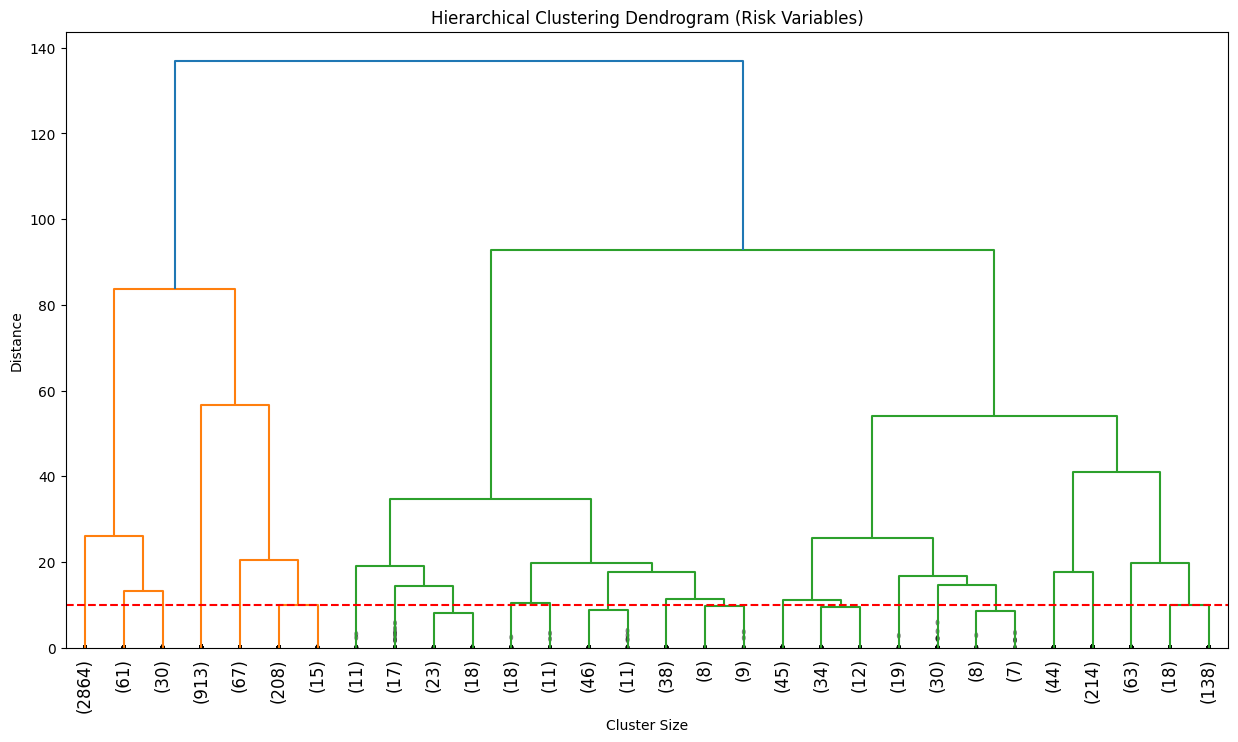

In [287]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Take a Random Sample
# We use 5,000 points to get a clear picture
idx = np.random.choice(X_risk_prepared.shape[0], 5000, replace=False)
X_sample = X_risk_prepared[idx]

# Compute Linkage Matrix - calculate the distances between clusters
Z = linkage(X_sample, method='ward')

# Plot the Dendrogram
plt.figure(figsize=(15, 8))
plt.title('Hierarchical Clustering Dendrogram (Risk Variables)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')

dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
    show_leaf_counts=True,
)

plt.axhline(y=10, color='r', linestyle='--')
plt.show()

Looking at the dendrogram, we see that there are long vertical lines (distinct groups) between distance 140 and 40, and if we were to draw a horizontal line across the chart at distance 55, we would slice through exactly 5 distinct vertical lines (3 in the Orange section, 2 in the Green section). This indicates that these 5 groups are fundamentally distinct from one another. If we were to cut lower at the dotted red line, it would lead to over-segmentation, splitting into clusters that have minute differences. 5 clusters also aligns very well with the Suicide Risk Continuum Theory, which states that suicidal thoughts and behaviors exist on a spectrum. We use this to create our 5 groups of 'No Risk', 'Frequent Attempters', 'Ideators & Planners', 'Severe Attempters', and 'Depressed (Non-Suicidal)'.

In [288]:
# Fit K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(principalComponents)

# Add cluster labels to the original dataframe
df_analysis = cluster_data_noyear.copy()
df_analysis['Cluster'] = labels

# Calculate the Mean for each cluster
cluster_profile = df_analysis.groupby('Cluster').mean()

print("Cluster Sizes:")
print(df_analysis['Cluster'].value_counts().sort_index())

Cluster Sizes:
Cluster
0    142034
1     11596
2     33392
3      3778
4     53044
Name: count, dtype: int64


We fit out k-means according to the the optimal 5 clusters that we found through the agglormerative clustering.

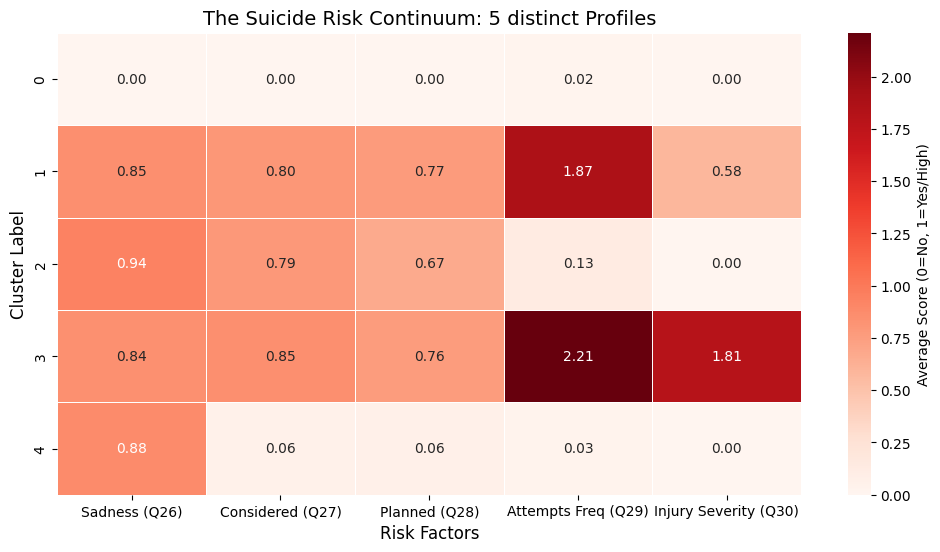

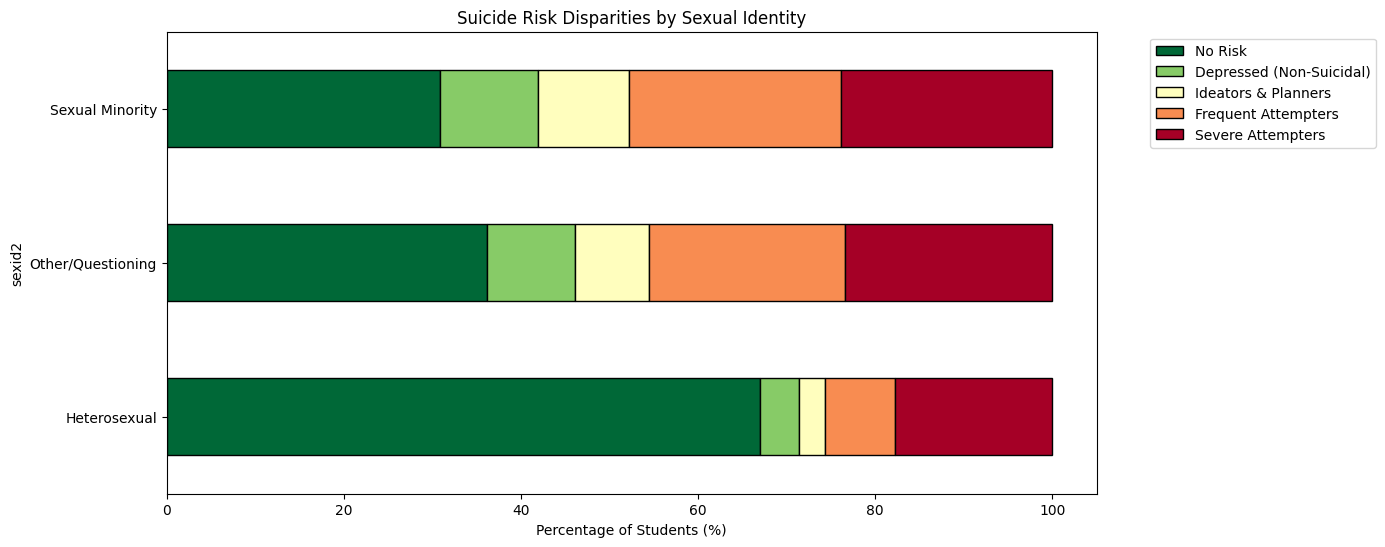

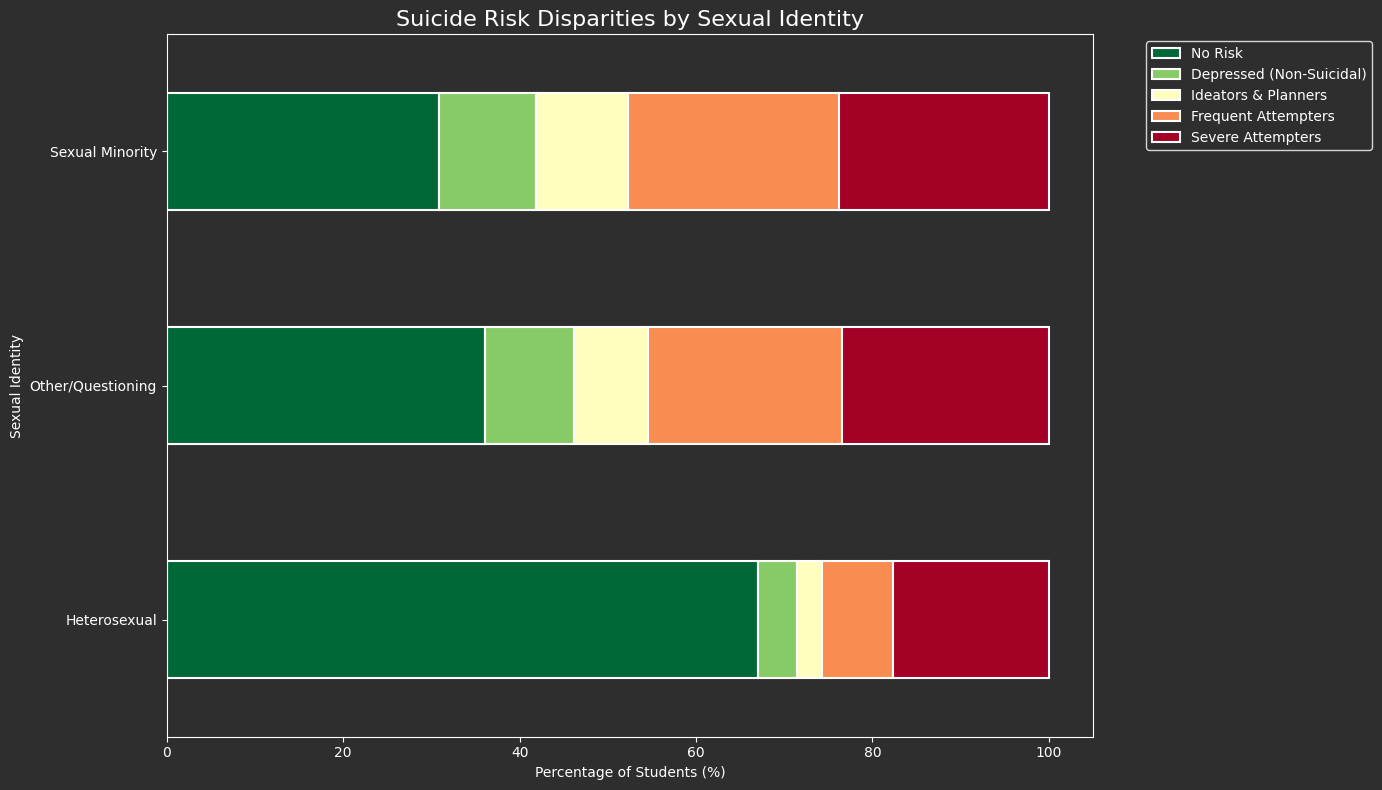

In [289]:
# Prepare data for final clustering with 5 clusters
binary_map = {'Yes': 1, 'A': 1, 'No': 0, 'B': 0}
freq_map = {
    '0 times': 0, 'A': 0, '1 time': 1, 'B': 1,
    '2 or 3 times': 2, 'C': 2, '4 or 5 times': 3, 'D': 3,
    '6 or more times': 4, 'E': 4
}
injury_map = {
    'I did not attempt suicide during the past 12 months': 0, 'A': 0,
    'No': 1, 'C': 1,  # Attempted, no injury
    'Yes': 2, 'B': 2  # Attempted, injury
}

numeric_df = cluster_data[['q26', 'q27', 'q28', 'q29', 'q30']].copy()

# numeric for clustering
numeric_df['q26'] = numeric_df['q26'].map(binary_map).fillna(0)
numeric_df['q27'] = numeric_df['q27'].map(binary_map).fillna(0)
numeric_df['q28'] = numeric_df['q28'].map(binary_map).fillna(0)
numeric_df['q29'] = numeric_df['q29'].map(freq_map).fillna(0)
numeric_df['q30'] = numeric_df['q30'].map(injury_map).fillna(0)

# Scale the data for clustering
risk_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])
X_scaled = risk_transformer.fit_transform(numeric_df)
# Fit K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
numeric_df['Risk_Label'] = labels
cluster_data['Risk_Label'] = labels
# Calculate the Mean for each cluster
readable_cols = {
    'q26': 'Sadness (Q26)',
    'q27': 'Considered (Q27)',
    'q28': 'Planned (Q28)',
    'q29': 'Attempts Freq (Q29)',
    'q30': 'Injury Severity (Q30)'
}
# Create a profile for each cluster
cluster_profile_plot = cluster_profile.rename(columns=readable_cols)
# Plot the cluster profiles as a heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_profile_plot,
    cmap='Reds',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Average Score (0=No, 1=Yes/High)'}
)

plt.title('The Suicide Risk Continuum: 5 distinct Profiles', fontsize=14)
plt.ylabel('Cluster Label', fontsize=12)
plt.xlabel('Risk Factors', fontsize=12)
plt.show()

# Map cluster labels to descriptive names
cluster_names = {
    0: 'No Risk',
    1: 'Frequent Attempters',
    2: 'Ideators & Planners',
    3: 'Severe Attempters',
    4: 'Depressed (Non-Suicidal)'
}
# Map cluster labels to descriptive names
cluster_data['Risk_Profile'] = cluster_data['Risk_Label'].map(cluster_names) # create map

# Risk distribution by sexual identity
risk_dist = pd.crosstab(
    cluster_data['sexid2'],
    cluster_data['Risk_Profile'],
    normalize='index'
) * 100

order = ['No Risk', 'Depressed (Non-Suicidal)', 'Ideators & Planners', 'Frequent Attempters', 'Severe Attempters']
risk_dist = risk_dist[order]

risk_dist.plot(kind='barh', stacked=True, figsize=(12, 6), colormap='RdYlGn_r', edgecolor='black')
plt.title('Suicide Risk Disparities by Sexual Identity')
plt.xlabel('Percentage of Students (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax = risk_dist.plot( # scale box plot based on values
    kind='barh',
    stacked=True,
    figsize=(14, 8),
    colormap='RdYlGn_r',
    edgecolor='white',
    linewidth=1.5
)

fig = plt.gcf()
fig.patch.set_facecolor('#2E2E2E') # Dark Grey figure background
ax.set_facecolor('#2E2E2E')        # Dark Grey plot area background

plt.title('Suicide Risk Disparities by Sexual Identity', fontsize=16, color='white')
plt.xlabel('Percentage of Students (%)', color='white')
plt.ylabel('Sexual Identity', color='white')

ax.tick_params(axis='x', colors='white') # make axis white
ax.tick_params(axis='y', colors='white')

ax.spines['bottom'].set_color('white') # makes edges white
ax.spines['top'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['right'].set_color('white')

legend = plt.legend( # make legend white
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    facecolor='#2E2E2E',
    edgecolor='white',
    labelcolor='white'
)

plt.tight_layout()
plt.savefig("suicide_risk.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()

The above cell just does a comprehensive overview of the previous cells, providing all of the mapping and data scaling all at once. It shows everything that was done, including our k-means with the optimal number of clusters, and visually representing the 5 groupings with the heatmap. The bar plot shows that Sexual Minority youth overall are at higher risk for suicidal ideation compared to heterosexual youth.